# Load Data

In [1]:
accepted_user_groups = [
    "GROUP_004",
    "GROUP_010",
    "GROUP_003",
    "GROUP_009",
    "GROUP_011",
    "GROUP_013",
    "GROUP_001",
    "GROUP_015", 
    "GROUP_012",
    "GROUP_005",
    "GROUP_006",
]

In [2]:
import pandas as pd
# Load the first CSV file
history = pd.read_csv('data_anon/admin_interactions.csv')
rankings = pd.read_csv('data_anon/llm_ranking_gpt-5.4_low.csv')
demographic = pd.read_csv('data_anon/admin_demographic_survey.csv')
survey = pd.read_csv('data_anon/admin_exit_survey.csv')
feedback = pd.read_csv('data_anon/admin_meeting_feedback.csv')

In [3]:
survey = survey.merge(
    demographic,
    on="user_id",
    how="left",
    suffixes=("", "_demographic")
)
survey = survey[survey["user_group"].isin(accepted_user_groups)]
survey = survey[survey["clinical_experience"] != "not_clinical"]
survey = survey.dropna(axis=1, how="all")
survey = survey.reset_index(drop=True)
# survey.to_csv("data/survey_filtered.csv", index=True)

In [4]:
survey

,user_id,user_group,timestamp,session_1_feedback_id,session_2_feedback_id,more_natural_llm,preferred_llm,visual_quality,sound_quality,conversation_quality,...,email_m3_id,user_group_demographic,timestamp_demographic,age,gender,race,clinical_experience,urmc_act_training,other_communication_training,interacted_with_sophie_before
0,98,GROUP_006,2026-07-28 06:35:48,186,187,HAL,either,4,4,3,...,[Redacted],GROUP_006,2026-07-28 06:35:48,25-34,woman,asian,attending,0,NaN,0
1,100,GROUP_006,2026-07-28 06:35:48,190,191,GPT-4o-mini,GPT-4o-mini,4,2,3,...,[Redacted],GROUP_006,2026-07-28 06:35:48,25-34,man,asian,attending,0,NaN,0
2,99,GROUP_006,2026-07-28 06:35:48,188,192,HAL,HAL,4,4,4,...,[Redacted],GROUP_006,2026-07-28 06:35:48,55-64,man,white,attending,0,NaN,0
3,103,GROUP_006,2026-07-28 06:35:48,193,194,GPT-4o-mini,GPT-4o-mini,4,3,3,...,[Redacted],GROUP_006,2026-07-28 06:35:48,45-54,woman,white,OB/GYN,0,I am enrolled in the RiseGuide,0
4,104,GROUP_006,2026-07-28 06:35:48,195,196,GPT-4o-mini,HAL,4,5,5,...,[Redacted],GROUP_006,2026-07-28 06:35:48,35-44,man,black,Family Medicine Physician at Residency Program,0,Implicit Bias Training,0
5,105,GROUP_005,2026-07-28 06:35:48,197,199,GPT-4o-mini,either,4,4,2,...,[Redacted],GROUP_005,2026-07-28 06:35:48,25-34,man,white,MD/PhD G3,0,NaN,0
6,106,GROUP_005,2026-07-28 06:35:48,200,201,GPT-4o-mini,either,5,4,3,...,[Redacted],GROUP_005,2026-07-28 06:35:48,18-24,woman,latino,medical_student,0,NaN,0
7,107,GROUP_006,2026-07-28 06:35:48,202,203,GPT-4o-mini,GPT-4o-mini,4,3,3,...,[Redacted],GROUP_006,2026-07-28 06:35:48,25-34,man,asian,attending,0,NaN,0
8,109,GROUP_006,2026-07-28 06:35:48,204,205,GPT-4o-mini,GPT-4o-mini,3,2,3,...,[Redacted],GROUP_006,2026-07-28 06:35:48,35-44,man,prefer_not,attending,0,NaN,0
9,111,GROUP_006,2026-07-28 06:35:48,207,209,GPT-4o-mini,GPT-4o-mini,5,5,5,...,[Redacted],GROUP_006,2026-07-28 06:35:48,55-64,man,asian,attending,0,NaN,0


In [5]:
survey.columns

Index(['user_id', 'user_group', 'timestamp', 'session_1_feedback_id',
       'session_2_feedback_id', 'more_natural_llm', 'preferred_llm',
       'visual_quality', 'sound_quality', 'conversation_quality',
       'more_natural_session', 'preferred_model', 'communication_improved',
       'felt_engaged', 'scenarios_appropriate', 'virtual_patients_realistic',
       'feedback_helpful', 'anticipate_using_skills', 'ai_less_stressful',
       'will_continue_using', 'will_recommend', 'recommend_email_text',
       'felt_genuine_empathy', 'hard_to_feel_real_empathy',
       'no_empathy_harder_to_express', 'empathy_can_be_taught',
       'empathize_improved', 'explicit_improved', 'empower_improved',
       'overall_improved', 'self_rating_empathize', 'self_rating_explicit',
       'self_rating_empower', 'self_rating_overall', 'use_frequently',
       'unnecessarily_complex', 'easy_to_use', 'need_technical_support',
       'well_integrated', 'too_inconsistent', 'learn_quickly', 'cumbersome',
   

In [6]:
completed_user_ids = list(set(survey['user_id']))

# Interactions

In [7]:
interactions = history.merge(
    rankings,
    on="feedback_id",
    how="inner"
)
interactions = interactions[interactions["user_id"].isin(completed_user_ids)]
interactions = interactions[['user_id', 'user_group', 'feedback_id', 'llm_used', 'meeting_duration_seconds', \
                             'timestamp_utc', 'transcript', 'LLM_SUM_EMPOWER', 'LLM_SUM_EXPLICIT', 'LLM_SUM_EMPATHY',\
                             'LLM_SUM_ALL']]
interactions = interactions[interactions["meeting_duration_seconds"] > 180].copy()
interactions = interactions.reset_index(drop=True)

interactions

,user_id,user_group,feedback_id,llm_used,meeting_duration_seconds,timestamp_utc,transcript,LLM_SUM_EMPOWER,LLM_SUM_EXPLICIT,LLM_SUM_EMPATHY,LLM_SUM_ALL
0,114,GROUP_006,218,HAL,192.993247,2026-08-01 13:22:58,[Redacted],0.244444,0.400000,0.333333,0.308333
1,114,GROUP_006,217,GPT-4o-mini,203.878303,2026-08-01 13:17:42,[Redacted],0.288889,0.314286,0.166667,0.250000
2,113,GROUP_006,214,GPT-4o-mini,520.128477,2026-07-31 13:42:55,[Redacted],0.488889,0.428571,0.400000,0.450000
3,113,GROUP_006,213,HAL,276.150958,2026-07-31 13:30:20,[Redacted],0.333333,0.400000,0.166667,0.300000
4,112,GROUP_006,212,GPT-4o-mini,240.283078,2026-07-30 19:14:06,[Redacted],0.311111,0.457143,0.466667,0.391667
...,...,...,...,...,...,...,...,...,...,...,...
135,9,GROUP_004,36,HAL,293.501492,2026-04-18 09:43:32,[Redacted],0.422222,0.457143,0.466667,0.441667
136,7,GROUP_004,34,HAL,325.495486,2026-04-13 11:10:36,[Redacted],0.600000,0.514286,0.666667,0.583333
137,7,GROUP_004,33,GPT-4o-mini,308.604378,2026-04-13 11:00:37,[Redacted],0.422222,0.542857,0.600000,0.500000
138,5,GROUP_004,32,HAL,377.168082,2026-04-10 10:26:57,[Redacted],0.288889,0.428571,0.566667,0.408333


In [8]:
interactions.columns

Index(['user_id', 'user_group', 'feedback_id', 'llm_used',
       'meeting_duration_seconds', 'timestamp_utc', 'transcript',
       'LLM_SUM_EMPOWER', 'LLM_SUM_EXPLICIT', 'LLM_SUM_EMPATHY',
       'LLM_SUM_ALL'],
      dtype='str')

### Number of interaction vs improvement

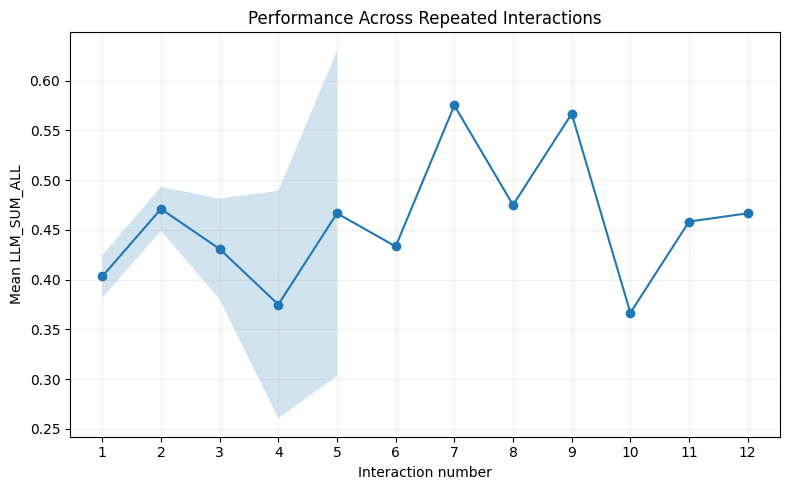

,interaction_no,mean_score,n,sem
0,1,0.403249,59,0.010855
1,2,0.471045,59,0.011317
2,3,0.430833,10,0.025821
3,4,0.375000,3,0.058333
4,5,0.466667,2,0.083333
5,6,0.433333,1,NaN
6,7,0.575000,1,NaN
7,8,0.475000,1,NaN
8,9,0.566667,1,NaN
9,10,0.366667,1,NaN


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = interactions.copy()

# Ensure proper types
df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"])
df["LLM_SUM_ALL"] = pd.to_numeric(df["LLM_SUM_ALL"], errors="coerce")

# Sort each user's interactions chronologically
df = df.sort_values(["user_id", "timestamp_utc"])

# Interaction number within each user
df["interaction_no"] = df.groupby("user_id").cumcount() + 1

# Mean performance at each interaction number
performance = (
    df.groupby("interaction_no")
    .agg(
        mean_score=("LLM_SUM_ALL", "mean"),
        n=("user_id", "nunique"),
        sem=("LLM_SUM_ALL", "sem"),
    )
    .reset_index()
)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    performance["interaction_no"],
    performance["mean_score"],
    marker="o",
)

# 95% CI
ax.fill_between(
    performance["interaction_no"],
    performance["mean_score"] - 1.96 * performance["sem"],
    performance["mean_score"] + 1.96 * performance["sem"],
    alpha=0.2,
)

ax.set_xlabel("Interaction number")
ax.set_ylabel("Mean LLM_SUM_ALL")
ax.set_title("Performance Across Repeated Interactions")
ax.set_xticks(performance["interaction_no"])
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

display(performance)

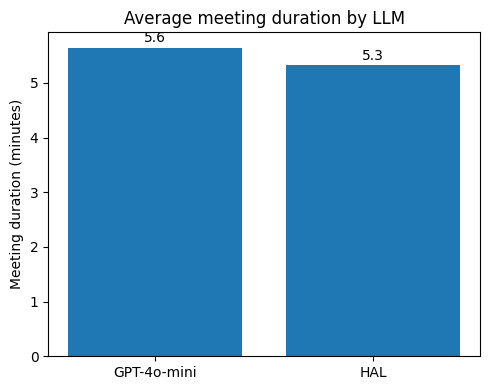

In [11]:
import matplotlib.pyplot as plt

# Convert to minutes
interactions["meeting_duration_min"] = interactions["meeting_duration_seconds"] / 60

# Aggregate (mean per model)
mean_duration = interactions.groupby("llm_used")["meeting_duration_min"].mean()

# Plot
plt.figure(figsize=(5,4))
plt.bar(mean_duration.index, mean_duration.values)

plt.ylabel("Meeting duration (minutes)")
plt.title("Average meeting duration by LLM")

# Add labels
for i, v in enumerate(mean_duration.values):
    plt.text(i, v + 0.1, f"{v:.1f}", ha="center")

plt.tight_layout()
plt.show()

In [5]:
# Measure communication score from transcript using GPT-5.4 (low)


# Download feedback
# Merge with feedback
# See if people improved on the feedback metrics on the second turn (e.g. speaking slower, using less filler words)

# Demographic Analysis

In [12]:
survey["gender"].value_counts()

gender
woman         33
man           25
prefer_not     1
Name: count, dtype: int64

In [18]:
survey["clinical_experience"]

0                                             attending
1                                             attending
2                                             attending
3                                                OB/GYN
4        Family Medicine Physician at Residency Program
5                                             MD/PhD G3
6                                       medical_student
7                                             attending
8                                             attending
9                                             attending
10                                      family medicine
11                                            attending
12                                    Internal Medicine
13                                            attending
14                              Obstetrics & Gynecology
15                                               OB GYN
16                                            attending
17                                Working Nurse 

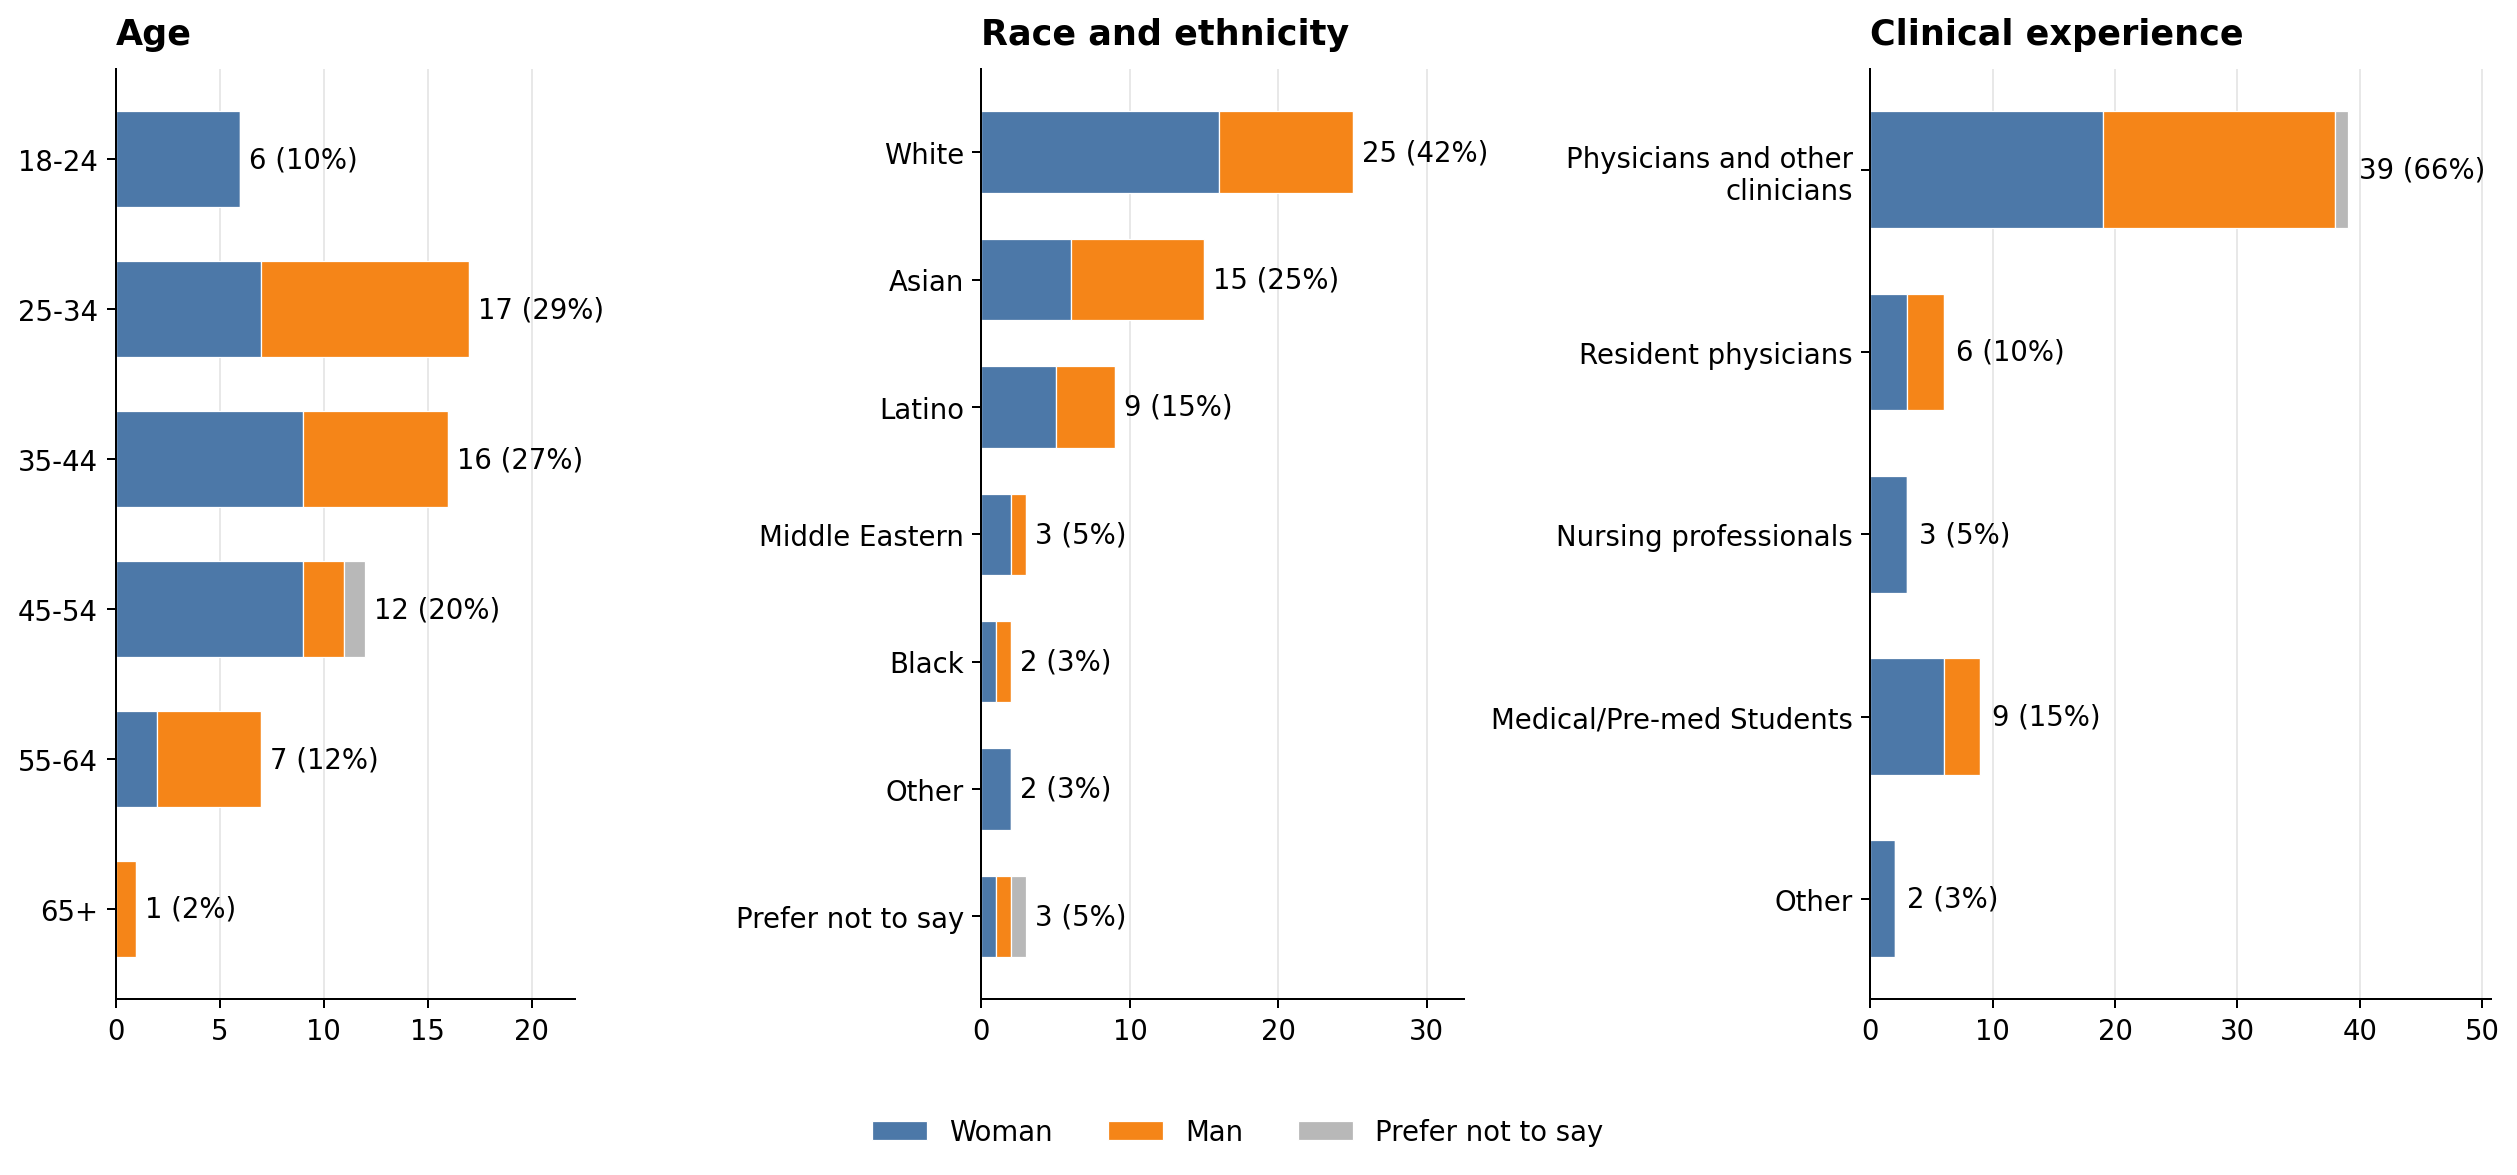

Total participants: 59
Saved: figures\participant_demographics_clean.pdf
Saved: figures\participant_demographics_clean.png


In [20]:
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Prepare display values ----------

def naturalize(series, mapping, default="Other"):
    normalized = series.astype("string").str.strip().str.casefold()
    result = normalized.map(mapping).fillna(default)
    result[series.isna() | normalized.isin(["", "nan", "none"])] = "Missing"
    return result


gender_map = {
    "woman": "Woman",
    "man": "Man",
    "prefer_not": "Prefer not to say",
}

race_map = {
    "white": "White",
    "asian": "Asian",
    "latino": "Latino",
    "middle_eastern": "Middle Eastern",
    "black": "Black",
    "other": "Other",
    "prefer_not": "Prefer not to say",
}

clinical_groups = {
    "Physicians and other clinicians": [
        "attending", "practitioner",
        "assistant professor of clinical dentistry",
        "family medicine", "family medicine physician at residency program",
        "general med", "general practice", "im", "internal medicine",
        "ob gyn", "ob/gyn", "obstetrics & gynecology",
        "palliative care", "palliative care physician",
    ],
    "Resident physicians": [
        "resident", "internal medicine resident",
    ],
    "Nursing professionals": [
        "registered nurse", "registered_nurse", "working nurse manager",
    ],
    "Medical/Pre-med Students": [
        "medical_student", "md/phd g3",
        "biomedical engineering student",
        "undergraduate pre-med student",
    ],
}

clinical_map = {
    value.casefold(): category
    for category, values in clinical_groups.items()
    for value in values
}

plot_df = survey.copy()
plot_df["gender_display"] = naturalize(
    plot_df["gender"], gender_map, default="Other"
)
plot_df["race_display"] = naturalize(
    plot_df["race"], race_map
)
plot_df["clinical_display"] = naturalize(
    plot_df["clinical_experience"], clinical_map
)

# ---------- Plot settings ----------

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 180,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

gender_order = ["Woman", "Man", "Prefer not to say", "Other", "Missing"]

gender_colors = {
    "Woman": "#4C78A8",
    "Man": "#F58518",
    "Prefer not to say": "#B8B8B8",
    "Other": "#72B7B2",
    "Missing": "#D9D9D9",
}

age_order = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

race_order = [
    "White", "Asian", "Latino", "Middle Eastern",
    "Black", "Other", "Prefer not to say", "Missing",
]

clinical_order = [
    "Physicians and other clinicians",
    "Resident physicians",
    "Nursing professionals",
    "Medical/Pre-med Students",
    "Other",
    "Missing",
]


def plot_panel(ax, category, title, order, wrap=None):
    tab = pd.crosstab(plot_df[category].fillna("Missing"),
                      plot_df["gender_display"].fillna("Missing"))

    rows = [x for x in order if x in tab.index]
    rows += [x for x in tab.index if x not in rows]
    tab = tab.reindex(rows)

    genders = [x for x in gender_order if x in tab.columns]
    totals = tab[genders].sum(axis=1)

    if tab.empty or totals.sum() == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_title(title, loc="left", fontweight="bold")
        return

    y = np.arange(len(tab))
    left = np.zeros(len(tab))

    for gender in genders:
        values = tab[gender].to_numpy()
        ax.barh(
            y, values, left=left, height=0.64,
            label=gender, color=gender_colors[gender],
            edgecolor="white", linewidth=0.5,
        )
        left += values

    labels = list(tab.index)
    if wrap:
        labels = [
            "\n".join(textwrap.wrap(str(x), wrap, break_long_words=False))
            for x in labels
        ]

    x_max = totals.max()
    grand_total = totals.sum()

    ax.set(
        yticks=y,
        yticklabels=labels,
        xlim=(0, max(1, x_max * 1.30)),
    )
    ax.invert_yaxis()
    ax.set_title(title, loc="left", fontweight="bold", pad=10)
    ax.grid(axis="x", color="#E5E5E5", linewidth=0.7)
    ax.set_axisbelow(True)

    for i, value in enumerate(totals):
        pct = 100 * value / grand_total
        ax.text(
            value + max(0.08, x_max * 0.025),
            i,
            f"{value} ({pct:.0f}%)",
            va="center",
        )


# ---------- Create and save figure ----------

fig, axes = plt.subplots(
    1, 3,
    figsize=(14.5, 6.8),
    gridspec_kw={"width_ratios": [1, 1.05, 1.35]},
)

plot_panel(axes[0], "age", "Age", age_order)
plot_panel(axes[1], "race_display", "Race and ethnicity", race_order)
plot_panel(
    axes[2],
    "clinical_display",
    "Clinical experience",
    clinical_order,
    wrap=25,
)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=len(labels),
    frameon=False,
)

fig.subplots_adjust(
    left=0.07,
    right=0.98,
    top=0.92,
    bottom=0.16,
    wspace=0.78,
)

output_dir = Path("figures")
output_dir.mkdir(exist_ok=True)

pdf_path = output_dir / "participant_demographics_clean.pdf"
png_path = output_dir / "participant_demographics_clean.png"

fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.2)
fig.savefig(png_path, bbox_inches="tight", pad_inches=0.08, dpi=600)
plt.show()

print(f"Total participants: {len(survey)}")
print(f"Saved: {pdf_path}")
print(f"Saved: {png_path}")

# Plotting parameters

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

survey = survey.copy()

n = len(set(list(survey['user_id'])))

# -----------------------------
# Pretty labels
# -----------------------------
label_map = {
    "session_1": "Session 1",
    "session_2": "Session 2",
    "no_difference": "No Difference",
    "either": "Either",
    "visual_quality": "Visual quality",
    "sound_quality": "Sound quality",
    "conversation_quality": "Conversation quality",
    "communication_improved": "Communication improved",
    "felt_engaged": "Felt engaged",
    "scenarios_appropriate": "Scenarios appropriate",
    "virtual_patients_realistic": "Virtual patients realistic",
    "feedback_helpful": "Feedback helpful",
    "anticipate_using_skills": "Will use skills",
    "ai_less_stressful": "AI less stressful",
    "will_continue_using": "Will continue using",
    "will_recommend": "Will recommend",
    "felt_genuine_empathy": "Felt genuine empathy",
    "hard_to_feel_real_empathy": "Hard to feel real empathy",
    "no_empathy_harder_to_express": "No empathy makes expression harder",
    "empathy_can_be_taught": "Empathy can be taught",
    "empathize_improved": "Empathize improved",
    "explicit_improved": "Be Explicit improved",
    "empower_improved": "Empower improved",
    "overall_improved": "Overall improved",
    "self_rating_empathize": "Self-rating: Empathize",
    "self_rating_explicit": "Self-rating: Be Explicit",
    "self_rating_empower": "Self-rating: Empower",
    "self_rating_overall": "Self-rating: Overall",
    "use_frequently": "Would use frequently",
    "unnecessarily_complex": "Unnecessarily complex",
    "easy_to_use": "Easy to use",
    "need_technical_support": "Need technical support",
    "well_integrated": "Well integrated",
    "too_inconsistent": "Too inconsistent",
    "learn_quickly": "Learn quickly",
    "cumbersome": "Cumbersome",
    "felt_confident": "Felt confident",
    "needed_to_learn_a_lot": "Need to learn a lot",
    "LLM_SUM_EMPOWER": "Empower",
    "LLM_SUM_EXPLICIT": "Be Explicit",
    "LLM_SUM_EMPATHY": "Empathy",
    "LLM_SUM_ALL": "Overall Score",
    "meeting_duration_seconds": "Meeting Duration",
    "reading_grade": "Reading Grade",
    "speaking_rate": "Speaking Rate",
    "num_questions": "Questions",
    "num_open_ended_questions": "Open-Ended Questions",
    "average_empathy": "Average Empathy",
    "personal_pronoun_count": "Personal Pronouns",
    "doctor_total_words": "Doctor Words",
    "doctor_total_turns": "Doctor Turns",
    "total_words": "Total Words",
    "num_hedge_words": "Hedge Words",
    "num_empathy_words": "Empathy Words",
    "doctor_total_words_norm": "Doctor Words",
    "speaking_rate_norm": "Speaking Rate",
    "reading_grade_norm": "Reading Grade",
    "num_hedge_words_norm": "Hedge Words",
}

# -----------------------------
# Matplotlib style
# -----------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Likert palette: 1..5
likert_colors = {
    1: "#B2182B",  # strong disagree / low
    2: "#EF8A62",
    3: "#D9D9D9",
    4: "#67A9CF",
    5: "#2166AC",  # strong agree / high
}

# For summary plots
summary_blue = "#4C78A8"
summary_green = "#54A24B"
summary_orange = "#F58518"
grid_color = "#E8E8E8"
text_color = "#2F2F2F"

figures = []

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

all_cols = [
    "doctor_total_words",
    "speaking_rate",
    "reading_grade",
    "num_hedge_words",
    "num_questions",
    "num_open_ended_questions",
    "num_empathy_words",
    "personal_pronoun_count",
    'LLM_SUM_EMPOWER', 
    'LLM_SUM_EXPLICIT', 
    'LLM_SUM_EMPATHY', 
    'LLM_SUM_ALL'
]

lower_better = [
    "doctor_total_words",
    "speaking_rate",
    "reading_grade",
    "num_hedge_words"
]

higher_better = [
    "num_questions",
    "num_open_ended_questions",
    "num_empathy_words",
    "personal_pronoun_count",
]

feedback_cols = lower_better + higher_better

eee_cols = [
    'LLM_SUM_EMPOWER', 
    'LLM_SUM_EXPLICIT', 
    'LLM_SUM_EMPATHY', 
    'LLM_SUM_ALL'
]

normalize_by_len = [
    "doctor_total_words",
    "num_hedge_words",
    "num_questions",
    "num_open_ended_questions",
    "num_empathy_words",
    "personal_pronoun_count",
    "num_hedge_words"
]



### Helpers

In [24]:
def clean_numeric_block(df, cols, min_val=1, max_val=5):
    out = df[cols].apply(pd.to_numeric, errors="coerce")
    out = out.where((out >= min_val) & (out <= max_val))
    return out


def plot_diverging_likert(df, cols, title, figsize=(10.5,4.5)):
    pct = build_likert_percent_table(df, cols)

    fig, ax = plt.subplots(figsize=(figsize[0], max(figsize[1], 0.32 * len(cols))))

    y = np.arange(len(cols))

    neg_left = -(pct[1] + pct[2]).values
    neg1 = pct[1].values
    neg2 = pct[2].values
    neu = pct[3].values
    pos4 = pct[4].values
    pos5 = pct[5].values

    ax.barh(y, neg1, left=neg_left, color=likert_colors[1], edgecolor="white", height=0.72, label="1")
    ax.barh(y, neg2, left=-pct[2].values, color=likert_colors[2], edgecolor="white", height=0.72, label="2")
    ax.barh(y, neu, left=-neu / 2, color=likert_colors[3], edgecolor="white", height=0.72, label="3")
    ax.barh(y, pos4, left=neu / 2, color=likert_colors[4], edgecolor="white", height=0.72, label="4")
    ax.barh(y, pos5, left=neu / 2 + pos4, color=likert_colors[5], edgecolor="white", height=0.72, label="5")

    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels([label_map.get(c, c) for c in cols])
    ax.invert_yaxis()
    ax.set_xlim(-100, 100)
    ax.set_xlabel("Response distribution (%)")
    # ax.set_title(title, loc="left", fontweight="bold")
    print(title)
    ax.grid(axis="x", color=grid_color, linewidth=0.8)
    ax.set_axisbelow(True)

    xticks = np.arange(-100, 101, 25)
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(abs(x)) for x in xticks])

    # Annotate positive agreement (4+5)
    pos_agree = pct[4] + pct[5]
    for i, val in enumerate(pos_agree.values):
        ax.text(102, i, f"{val:.0f}%", va="center", ha="left", fontsize=9, color=text_color)

    ax.legend(
        title="Likert",
        ncol=5,
        frameon=False,
        bbox_to_anchor=(0.5, -0.15),
        loc="upper center"
    )
    return fig


def plot_sus_split_likert(df, positive_cols, negative_cols, title, figsize=(10.5, 7.8)):
    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=figsize,
        gridspec_kw={"height_ratios": [len(positive_cols), len(negative_cols)]},
    )
    for ax, cols, subtitle in zip(
        axes,
        [positive_cols, negative_cols],
        ["Positive items", "Negative items"],
    ):
        pct = build_likert_percent_table(df, cols)
        y = np.arange(len(cols))

        neg_left = -(pct[1] + pct[2]).values
        neu = pct[3].values

        ax.barh(y, pct[1].values, left=neg_left, color=likert_colors[1], edgecolor="white", height=0.72, label="1")
        ax.barh(y, pct[2].values, left=-pct[2].values, color=likert_colors[2], edgecolor="white", height=0.72, label="2")
        ax.barh(y, neu, left=-neu / 2, color=likert_colors[3], edgecolor="white", height=0.72, label="3")
        ax.barh(y, pct[4].values, left=neu / 2, color=likert_colors[4], edgecolor="white", height=0.72, label="4")
        ax.barh(y, pct[5].values, left=neu / 2 + pct[4].values, color=likert_colors[5], edgecolor="white", height=0.72, label="5")

        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_yticks(y)
        ax.set_yticklabels([label_map.get(c, c) for c in cols])
        ax.invert_yaxis()
        ax.set_xlim(-100, 100)
        ax.set_title(subtitle, loc="left", fontweight="bold")
        ax.grid(axis="x", color=grid_color, linewidth=0.8)
        ax.set_axisbelow(True)

        xticks = np.arange(-100, 101, 25)
        ax.set_xticks(xticks)
        ax.set_xticklabels([str(abs(x)) for x in xticks])

    axes[-1].set_xlabel("Response distribution (%)")
    # fig.suptitle(title, x=0.01, ha="left", fontweight="bold", fontsize=13)\
    print(title)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Likert", ncol=5, frameon=False, loc="lower center",bbox_to_anchor=(0.5, -0.04))

    fig.tight_layout(rect=[0, 0.06, 1, 0.95])
    return fig

def plot_mean_ci_bars(df, cols, title, xlim=(1, 5), color=summary_blue, figsize=None):
    vals = clean_numeric_block(df, cols)
    means = vals.mean().sort_values()
    ses = vals.sem().reindex(means.index)

    if figsize is None:
        figsize = (8.2, max(3.8, 0.5 * len(cols)))

    fig, ax = plt.subplots(figsize=figsize)
    y = np.arange(len(means))

    ax.barh(y, means.values, color=color, edgecolor="none", height=0.68)
    ax.errorbar(
        means.values, y,
        xerr=1.96 * ses.values,
        fmt="none",
        ecolor="black",
        capsize=3,
        linewidth=1
    )

    ax.set_yticks(y)
    ax.set_yticklabels([label_map.get(c, c) for c in means.index])
    ax.set_xlim(*xlim)
    ax.set_xlabel("Mean response (1-5)")
    ax.set_title(title, loc="left", fontweight="bold")
    ax.grid(axis="x", color=grid_color, linewidth=0.8)
    ax.set_axisbelow(True)

    for i, (m, se) in enumerate(zip(means.values, ses.values)):
        upper_ci = m + 1.96 * se
        ax.text(upper_ci + 0.05, i, f"{m:.2f}", va="center", ha="left", color=text_color,)

    return fig

def build_likert_percent_table(df, cols):
    vals = clean_numeric_block(df, cols)
    table = []
    for col in cols:
        counts = vals[col].value_counts(normalize=True).reindex([1, 2, 3, 4, 5], fill_value=0.0) * 100
        table.append(counts.values)
    return pd.DataFrame(table, index=cols, columns=[1, 2, 3, 4, 5])


def plot_topbox(df, cols, title, positive_values=(4, 5), color=summary_green, figsize=(8.2, 3.8)):
    vals = clean_numeric_block(df, cols)
    pct = vals.apply(lambda s: s.isin(positive_values).mean() * 100)
    pct = pct.sort_values()

    fig, ax = plt.subplots(figsize=(figsize[0], max(figsize[1], 0.28 * len(cols))))
    y = np.arange(len(pct))
    ax.barh(y, pct.values, color=color, edgecolor="none", height=0.68)
    ax.set_yticks(y)
    ax.set_yticklabels([label_map.get(c, c) for c in pct.index])
    ax.set_xlim(0, 100)
    ax.set_xlabel("Top-box agreement (%)")
    # ax.set_title(title, loc="left", fontweight="bold")
    print(title)
    ax.grid(axis="x", color=grid_color, linewidth=0.8)
    ax.set_axisbelow(True)

    for i, v in enumerate(pct.values):
        ax.text(v + 1.2, i, f"{v:.0f}%", va="center", ha="left")

    return fig

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, t

def plot_session_comparison(session_1, session_2, cols, label1="Session 1",
                            label2="Session 2", alternative="greater", figsize=(12, 5)):

    combined = pd.concat([
        session_1[cols].assign(session=label1),
        session_2[cols].assign(session=label2)
    ])
    combined[cols] /= combined[cols].std()

    g = combined.groupby("session")[cols]
    means, sems, ns = g.mean(), g.sem(), g.count()
    cis = sems * ns.apply(lambda n: t.ppf(.975, n - 1))

    x, w = np.arange(len(cols)), .38
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(x-w/2, means.loc[label1], w, yerr=cis.loc[label1], capsize=4, label=label1)
    ax.bar(x+w/2, means.loc[label2], w, yerr=cis.loc[label2], capsize=4, label=label2)
    ax.set_xticks(x, [label_map.get(c, c) for c in cols], rotation=30, ha="right")
    ax.set_ylabel("Mean / SD")
    ax.legend(loc="lower center", bbox_to_anchor=(.5, 1.02), ncol=2, frameon=False)
    plt.tight_layout()
    plt.show()

    paired = session_1[["user_id"] + cols].merge(
        session_2[["user_id"] + cols], on="user_id", suffixes=("_1", "_2")
    )

    rows = []
    for col in cols:
        a, b = paired[f"{col}_1"], paired[f"{col}_2"]
        valid = a.notna() & b.notna()
        a, b = a[valid], b[valid]
        d, n = b - a, valid.sum()
        ts, p = ttest_rel(b, a, alternative=alternative)
        margin = t.ppf(.975, n-1) * d.sem()

        rows.append([
            col, n, a.mean(), b.mean(), d.mean(),
            d.mean()-margin, d.mean()+margin, ts, p, p < .05
        ])

    results = pd.DataFrame(rows, columns=[
        "Metric", "N", f"{label1} Mean", f"{label2} Mean",
        "Difference", "95% CI Low", "95% CI High", "t", "p", "Significant"
    ])

    display(results.style.format({
        f"{label1} Mean": "{:.3f}", f"{label2} Mean": "{:.3f}",
        "Difference": "{:.3f}", "95% CI Low": "{:.3f}",
        "95% CI High": "{:.3f}", "t": "{:.3f}", "p": "{:.4f}"
    }))


# Exit Survey Analysis

In [26]:
survey.columns

Index(['user_id', 'user_group', 'timestamp', 'session_1_feedback_id',
       'session_2_feedback_id', 'more_natural_llm', 'preferred_llm',
       'visual_quality', 'sound_quality', 'conversation_quality',
       'more_natural_session', 'preferred_model', 'communication_improved',
       'felt_engaged', 'scenarios_appropriate', 'virtual_patients_realistic',
       'feedback_helpful', 'anticipate_using_skills', 'ai_less_stressful',
       'will_continue_using', 'will_recommend', 'recommend_email_text',
       'felt_genuine_empathy', 'hard_to_feel_real_empathy',
       'no_empathy_harder_to_express', 'empathy_can_be_taught',
       'empathize_improved', 'explicit_improved', 'empower_improved',
       'overall_improved', 'self_rating_empathize', 'self_rating_explicit',
       'self_rating_empower', 'self_rating_overall', 'use_frequently',
       'unnecessarily_complex', 'easy_to_use', 'need_technical_support',
       'well_integrated', 'too_inconsistent', 'learn_quickly', 'cumbersome',
   

In [27]:
survey

,user_id,user_group,timestamp,session_1_feedback_id,session_2_feedback_id,more_natural_llm,preferred_llm,visual_quality,sound_quality,conversation_quality,...,email_m3_id,user_group_demographic,timestamp_demographic,age,gender,race,clinical_experience,urmc_act_training,other_communication_training,interacted_with_sophie_before
0,98,GROUP_006,2026-07-28 06:35:48,186,187,HAL,either,4,4,3,...,[Redacted],GROUP_006,2026-07-28 06:35:48,25-34,woman,asian,attending,0,NaN,0
1,100,GROUP_006,2026-07-28 06:35:48,190,191,GPT-4o-mini,GPT-4o-mini,4,2,3,...,[Redacted],GROUP_006,2026-07-28 06:35:48,25-34,man,asian,attending,0,NaN,0
2,99,GROUP_006,2026-07-28 06:35:48,188,192,HAL,HAL,4,4,4,...,[Redacted],GROUP_006,2026-07-28 06:35:48,55-64,man,white,attending,0,NaN,0
3,103,GROUP_006,2026-07-28 06:35:48,193,194,GPT-4o-mini,GPT-4o-mini,4,3,3,...,[Redacted],GROUP_006,2026-07-28 06:35:48,45-54,woman,white,OB/GYN,0,I am enrolled in the RiseGuide,0
4,104,GROUP_006,2026-07-28 06:35:48,195,196,GPT-4o-mini,HAL,4,5,5,...,[Redacted],GROUP_006,2026-07-28 06:35:48,35-44,man,black,Family Medicine Physician at Residency Program,0,Implicit Bias Training,0
5,105,GROUP_005,2026-07-28 06:35:48,197,199,GPT-4o-mini,either,4,4,2,...,[Redacted],GROUP_005,2026-07-28 06:35:48,25-34,man,white,MD/PhD G3,0,NaN,0
6,106,GROUP_005,2026-07-28 06:35:48,200,201,GPT-4o-mini,either,5,4,3,...,[Redacted],GROUP_005,2026-07-28 06:35:48,18-24,woman,latino,medical_student,0,NaN,0
7,107,GROUP_006,2026-07-28 06:35:48,202,203,GPT-4o-mini,GPT-4o-mini,4,3,3,...,[Redacted],GROUP_006,2026-07-28 06:35:48,25-34,man,asian,attending,0,NaN,0
8,109,GROUP_006,2026-07-28 06:35:48,204,205,GPT-4o-mini,GPT-4o-mini,3,2,3,...,[Redacted],GROUP_006,2026-07-28 06:35:48,35-44,man,prefer_not,attending,0,NaN,0
9,111,GROUP_006,2026-07-28 06:35:48,207,209,GPT-4o-mini,GPT-4o-mini,5,5,5,...,[Redacted],GROUP_006,2026-07-28 06:35:48,55-64,man,asian,attending,0,NaN,0


In [42]:
survey[['user_id', 'more_natural_llm', 'preferred_llm']]

,user_id,more_natural_llm,preferred_llm
0,98,HAL,either
1,100,GPT-4o-mini,GPT-4o-mini
2,99,HAL,HAL
3,103,GPT-4o-mini,GPT-4o-mini
4,104,GPT-4o-mini,HAL
5,105,GPT-4o-mini,either
6,106,GPT-4o-mini,either
7,107,GPT-4o-mini,GPT-4o-mini
8,109,GPT-4o-mini,GPT-4o-mini
9,111,GPT-4o-mini,GPT-4o-mini


### Human-likeness Overall System

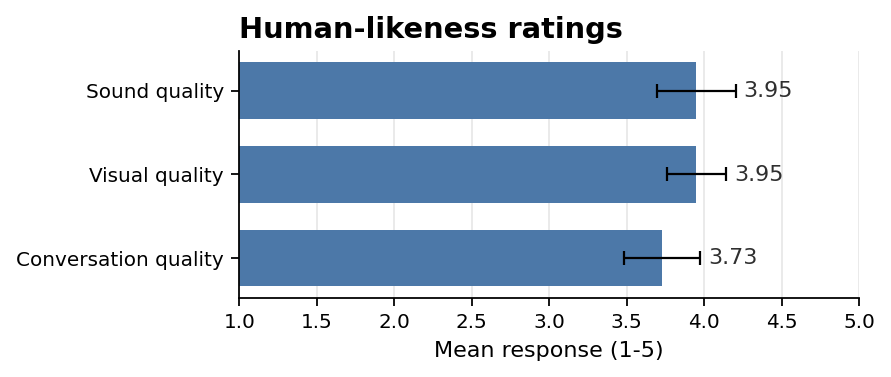

In [43]:
human_likeness_cols = [
    "visual_quality",
    "sound_quality",
    "conversation_quality",
]

# 1. Human-likeness mean scores
figures.append(
    plot_mean_ci_bars(
        survey,
        human_likeness_cols,
        "Human-likeness ratings",
        xlim=(1, 5),
        color=summary_blue,
        figsize=(5,2)
    )
)

### Human-likeness in LLM Comparison

Which session felt more natural and human-like?
Which model would participants prefer to speak to again?
Which LLM felt more natural and human-like?
Which LLM would participants prefer to speak to again?


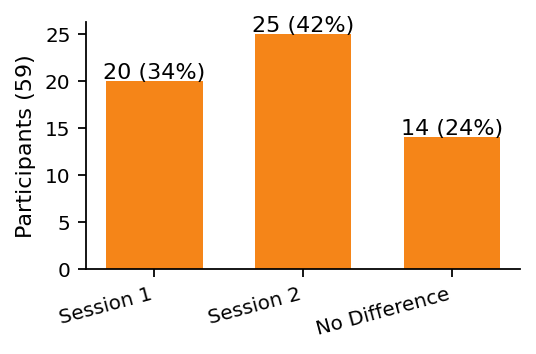

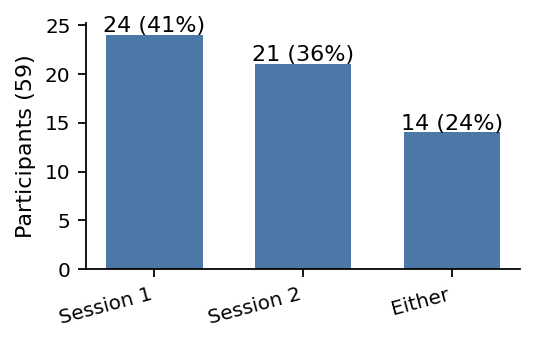

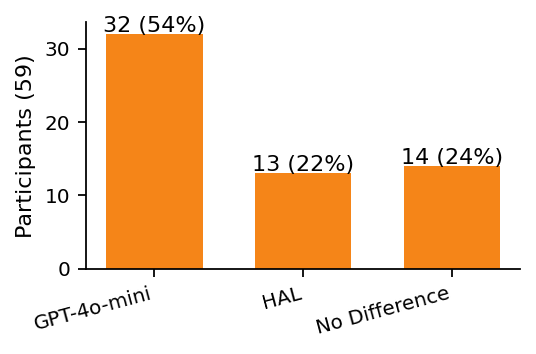

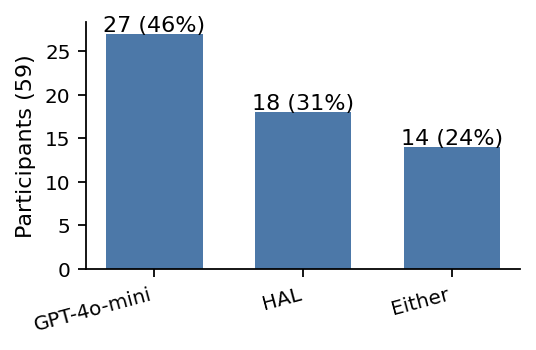

In [56]:
def plot_preference_counts(
    df, col, title, order=None, color=summary_orange
):
    counts = df[col].replace({"nan": np.nan}).dropna().value_counts()

    if order:
        counts = counts.reindex(
            [x for x in order if x in counts.index]
            + [x for x in counts.index if x not in order]
        )

    fig, ax = plt.subplots(figsize=(3.5, 2))
    x = np.arange(len(counts))

    labels = [
        label_map.get(value, value) if label_map else value
        for value in counts.index
    ]

    ax.bar(x, counts.values, color=color, edgecolor="none", width=0.65)
    ax.set_xticks(x, labels, rotation=15, ha="right")
    ax.set_ylabel(f"Participants ({n})")

    print(title)
    total = counts.sum()

    for i, value in enumerate(counts):
        ax.text(
            i,
            value + 0.3,
            f"{value} ({100 * value / total:.0f}%)",
            ha="center",
        )

    return fig


# 8. Preference questions if present
if "more_natural_session" in survey.columns:
    figures.append(
        plot_preference_counts(
            survey,
            "more_natural_session",
            "Which session felt more natural and human-like?",
            order=["session_1", "session_2"],
            color=summary_orange,
        )
    )

if "preferred_model" in survey.columns:
    figures.append(
        plot_preference_counts(
            survey,
            "preferred_model",
            "Which model would participants prefer to speak to again?",
            color=summary_blue,
        )
    )

# 9. Preference questions if present
if "more_natural_llm" in survey.columns:
    figures.append(
        plot_preference_counts(
            survey,
            "more_natural_llm",
            "Which LLM felt more natural and human-like?",
            order=["GPT-4o-mini", "HAL"],
            color=summary_orange,
        )
    )

if "preferred_llm" in survey.columns:
    figures.append(
        plot_preference_counts(
            survey,
            "preferred_llm",
            "Which LLM would participants prefer to speak to again?",
            color=summary_blue,
        )
    )

### Educational value

Educational value response distribution
Educational value: percent somewhat/strongly agree


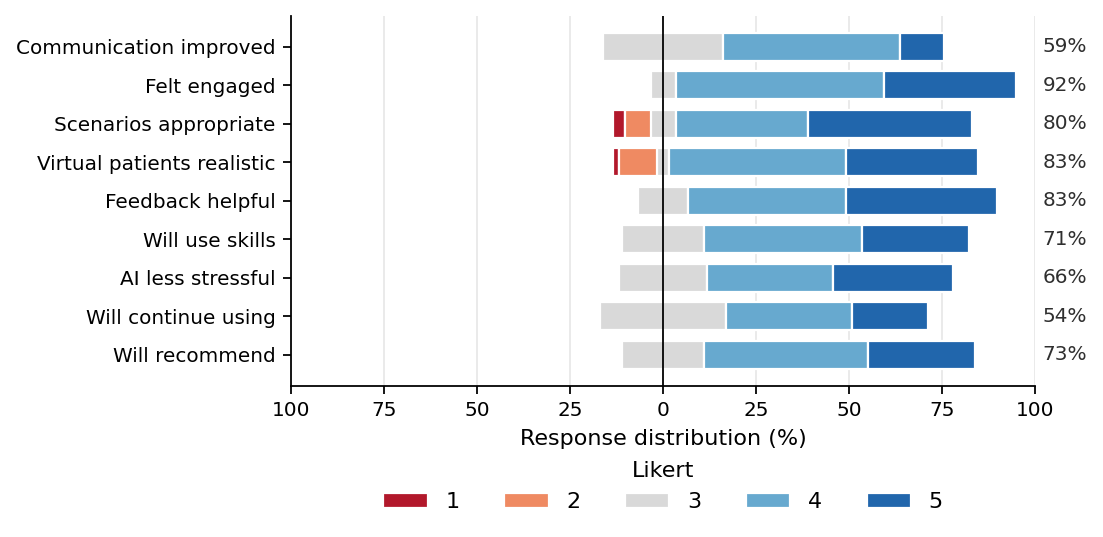

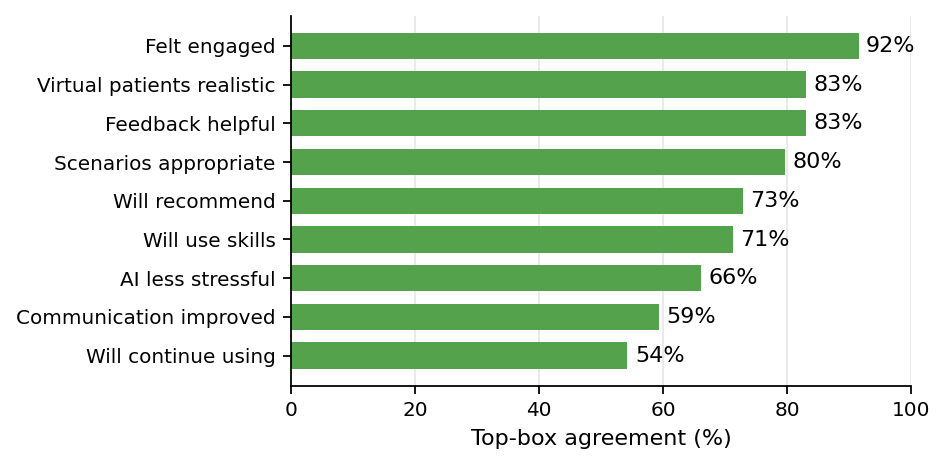

In [57]:
educational_value_cols = [
    "communication_improved",
    "felt_engaged",
    "scenarios_appropriate",
    "virtual_patients_realistic",
    "feedback_helpful",
    "anticipate_using_skills",
    "ai_less_stressful",
    "will_continue_using",
    "will_recommend",
]

# 2. Educational value as diverging Likert
figures.append(
    plot_diverging_likert(
        survey,
        educational_value_cols,
        "Educational value response distribution",
        figsize=(6,3)
    )
)

# 6. Top-box agreement for educational value
figures.append(
    plot_topbox(
        survey,
        educational_value_cols,
        "Educational value: percent somewhat/strongly agree",
        positive_values=(4, 5),
        color=summary_green,
        figsize=(5,3)
    )
)

In [58]:
import os
os.makedirs("figures", exist_ok=True)

figure_names = [
    "human_likeness_ratings",
    "educational_value_distribution",
    "self_perception_distribution",
    "self_rated_communication_skills",
    "system_usability_distribution",
    "educational_value_topbox",
    "system_usability_topbox",
    "more_natural_session",
    "preferred_model",
    "more_natural_llm",
    "preferred_llm"
]

for fig, name in zip(figures, figure_names):
    output_pdf = f"figures/{name}.pdf"
    fig.savefig(output_pdf, bbox_inches="tight")
    print(f"Saved: {output_pdf}")

plt.show()

Saved: figures/human_likeness_ratings.pdf
Saved: figures/educational_value_distribution.pdf
Saved: figures/self_perception_distribution.pdf
Saved: figures/self_rated_communication_skills.pdf
Saved: figures/system_usability_distribution.pdf
Saved: figures/educational_value_topbox.pdf
Saved: figures/system_usability_topbox.pdf
Saved: figures/more_natural_session.pdf
Saved: figures/preferred_model.pdf
Saved: figures/more_natural_llm.pdf
Saved: figures/preferred_llm.pdf


### Self-perception

3E self-perception response distribution


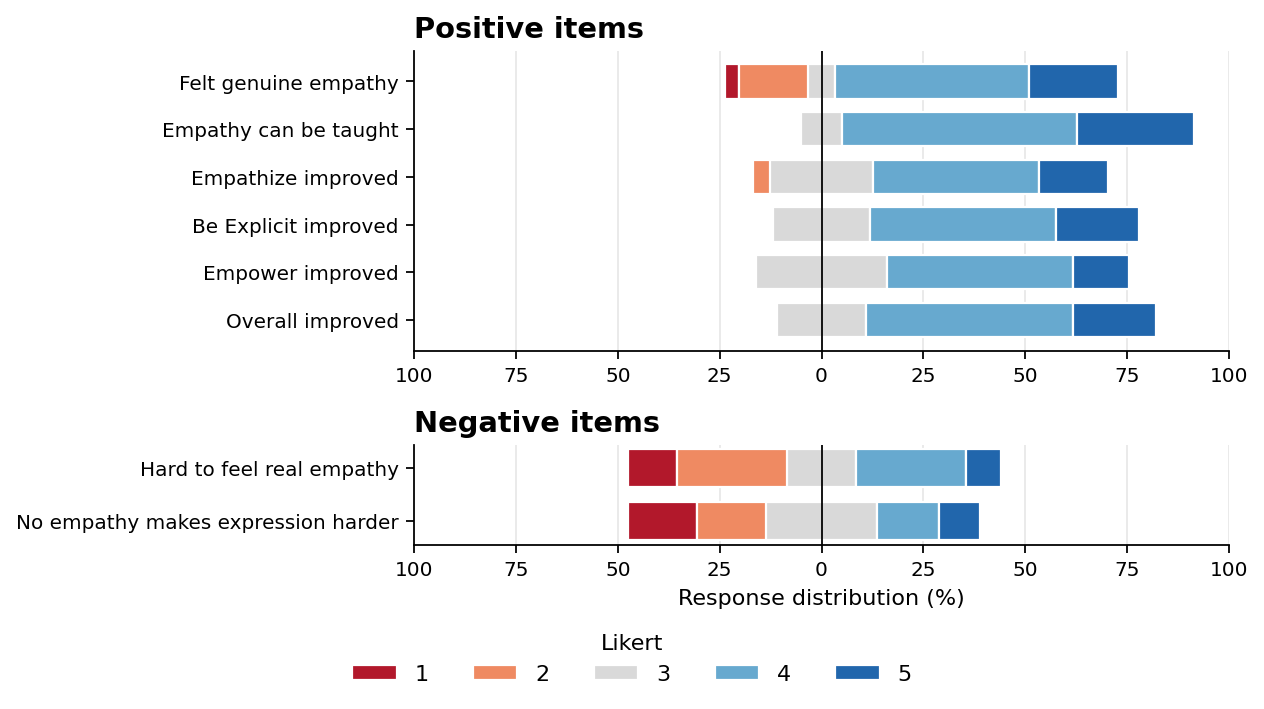

In [59]:
self_perception_positive_cols = [
    "felt_genuine_empathy",
    "empathy_can_be_taught",
    "empathize_improved",
    "explicit_improved",
    "empower_improved",
    "overall_improved",
]

self_perception_negative_cols = [
    "hard_to_feel_real_empathy",
    "no_empathy_harder_to_express",
]

# 3. 3E self-perception as diverging Likert
figures.append(
    plot_sus_split_likert(
        survey,
        self_perception_positive_cols,
        self_perception_negative_cols,
        "3E self-perception response distribution",
        (8,4.5)
    )
)

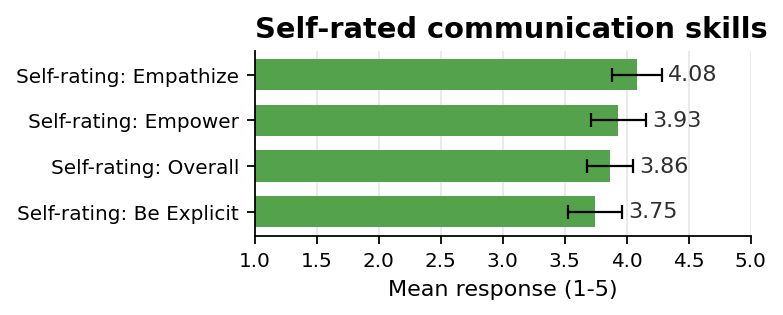

In [60]:
self_rating_cols = [
    "self_rating_empathize",
    "self_rating_explicit",
    "self_rating_empower",
    "self_rating_overall",
]

# 4. Self-ratings as mean bars
figures.append(
    plot_mean_ci_bars(
        survey,
        self_rating_cols,
        "Self-rated communication skills",
        xlim=(1, 5),
        color=summary_green,
        figsize=(4,1.5)
    )
)


### System Usability Scale

System usability response distribution
System usability: percent somewhat/strongly agree


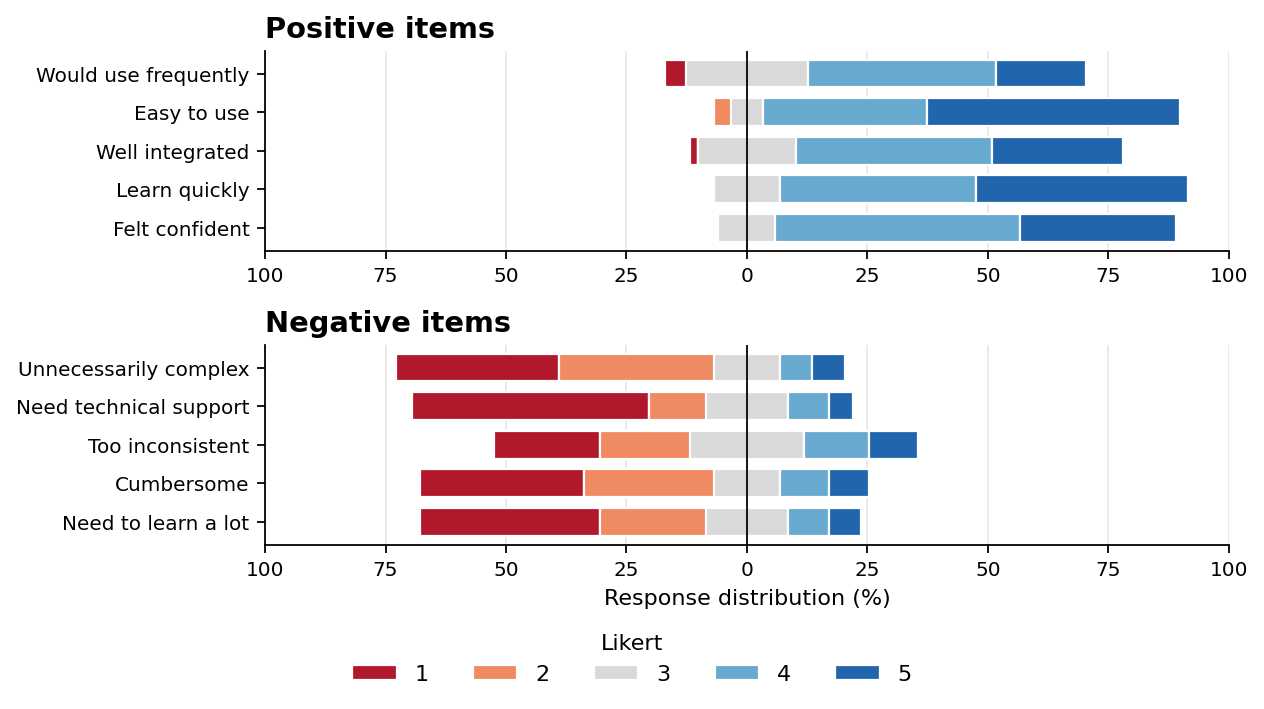

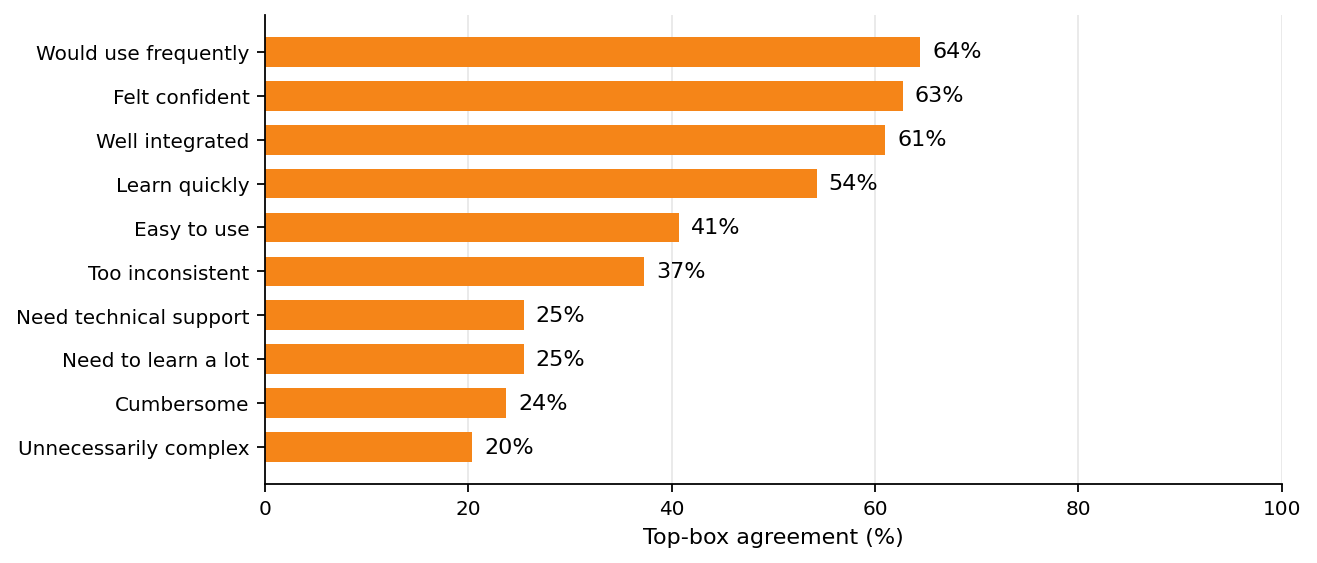

In [61]:
sus_positive_cols = [
    "use_frequently",
    "easy_to_use",
    "well_integrated",
    "learn_quickly",
    "felt_confident",
]

sus_negative_cols = [
    "unnecessarily_complex",
    "need_technical_support",
    "too_inconsistent",
    "cumbersome",
    "needed_to_learn_a_lot",
]

sus_cols = [
    "use_frequently",
    "easy_to_use",
    "well_integrated",
    "learn_quickly",
    "felt_confident",
    "unnecessarily_complex",
    "need_technical_support",
    "too_inconsistent",
    "cumbersome",
    "needed_to_learn_a_lot",
]



# 5. SUS-related items as diverging Likert
figures.append(
    plot_sus_split_likert(
        survey,
        sus_positive_cols,
        sus_negative_cols,
        "System usability response distribution",
        (8,4.5)
    )
)

# 7. Top-box agreement for SUS
figures.append(
    plot_topbox(
        survey,
        sus_cols,
        "System usability: percent somewhat/strongly agree",
        positive_values=(4, 3),
        color=summary_orange,
    )
)

### Save each figure independently

# Feedback Analysis ❌ (Too noisy)

In [68]:
feedback = pd.read_csv('data_anon/admin_meeting_feedback.csv')

In [69]:
feedback = feedback[
    feedback["id"].isin(interactions["feedback_id"])
].copy()

feedback["num_empathy_words"] = feedback["empathy_word_cloud_text"].fillna("").str.split().str.len()
feedback = feedback.drop(columns=['meeting_id', 'student_email', 'user_fname', 'user_lname'])
feedback

,id,module,scenario,follow_up,feedback_timestamp,actionable_feedback,meeting_transcript,hedge_word_cloud_text,num_hedge_words,empathy_word_cloud_text,...,average_empathy,personal_pronoun_count,doctor_total_words,doctor_total_turns,total_words,num_empathy_words,meeting_duration_seconds,user_id,llm_used,llm_admin_override
0,31,act,scenario8,0,2026-04-10 10:18:07,"<h2><span style=""color:green;""><b>Empower</b><...",[Redacted],so Well like Well So quite so So so So well So...,20,Sorry Understand Support Feel,...,1.250000,16.0,455.0,9.0,910.0,4,322.672740,5,GPT-4o-mini,0
1,32,act,scenario11,0,2026-04-10 10:26:57,"<h2><span style=""color:#1e90ff;""><b>Empower</b...",[Redacted],So So um so So could like could So So so well ...,19,Sorry Support Support Feel Support Comfort Sup...,...,1.250000,33.0,696.0,9.0,1392.0,9,377.168082,5,HAL,0
2,33,act,scenario9,0,2026-04-13 11:00:37,"<h2><span style=""color:#1976D2;"">Empower</span...",[Redacted],so so Okay So okay like okay Okay so So so So ...,26,Sorry Understand Sorry Feel Understand Sorry,...,0.428571,26.0,397.0,22.0,794.0,6,308.604378,7,GPT-4o-mini,0
3,34,act,scenario12,0,2026-04-13 11:10:36,"<h2><span style=""color: #006400;""><b>Empower</...",[Redacted],so so So basically right Alright Okay So Alright,9,Sorry Sorry,...,2.500000,38.0,415.0,21.0,830.0,2,325.495486,7,HAL,0
5,36,act,scenario8,0,2026-04-18 09:43:32,"<h2><span style=""color:green;""><b>What Went We...",[Redacted],So So well right So probably so hmm rather So ...,31,Understand Feeling Concerned Understand Feel S...,...,1.454545,22.0,387.0,12.0,774.0,9,293.501492,9,HAL,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,212,act,scenario17,0,2026-07-30 19:14:06,"<h2><span style=""color:green;""><b>Strengths (W...",[Redacted],Well Well so right so right probably So may mi...,15,Sorry Sorry Support,...,1.200000,28.0,374.0,15.0,748.0,3,240.283078,112,GPT-4o-mini,0
165,213,imclerkship,scenario1,0,2026-07-31 13:30:20,"<h2><span style=""color:#2e6da4;""><b>Empower</b...",[Redacted],okay okay Okay okay Okay So rather So well lik...,36,Feel Feel Feel Feel,...,0.285714,20.0,603.0,15.0,1206.0,4,276.150958,113,HAL,0
166,214,act,scenario8,0,2026-07-31 13:42:55,"<h2><span style=""color: #2E8B57;""><b>Strengths...",[Redacted],So Okay Well So like like So right So somewhat...,54,Feeling Understand Feel Feel Feeling Encourage...,...,0.545455,63.0,1115.0,12.0,2230.0,9,520.128477,113,GPT-4o-mini,0
169,217,act,scenario19,0,2026-08-01 13:17:42,"<h2><span style=""color:#2E8B57;""><b>Empower</b...",[Redacted],appears probably So could Okay maybe like So S...,15,Concerned Understand Understand Understand,...,1.000000,20.0,392.0,6.0,784.0,4,203.878303,114,GPT-4o-mini,0


In [70]:
feedback.columns, len(feedback)

(Index(['id', 'module', 'scenario', 'follow_up', 'feedback_timestamp',
        'actionable_feedback', 'meeting_transcript', 'hedge_word_cloud_text',
        'num_hedge_words', 'empathy_word_cloud_text', 'linechart_data', 'turns',
        'speaker_names', 'reading_grade', 'speaking_rate', 'num_questions',
        'num_open_ended_questions', 'average_empathy', 'personal_pronoun_count',
        'doctor_total_words', 'doctor_total_turns', 'total_words',
        'num_empathy_words', 'meeting_duration_seconds', 'user_id', 'llm_used',
        'llm_admin_override'],
       dtype='str'),
 140)

In [71]:
valid_feedback_ids = list(survey['session_1_feedback_id']) + list(survey['session_2_feedback_id'])
valid_feedback_ids.sort()

In [72]:
feedback = feedback[feedback["id"].isin(valid_feedback_ids)].reset_index(drop=True)
feedback

,id,module,scenario,follow_up,feedback_timestamp,actionable_feedback,meeting_transcript,hedge_word_cloud_text,num_hedge_words,empathy_word_cloud_text,...,average_empathy,personal_pronoun_count,doctor_total_words,doctor_total_turns,total_words,num_empathy_words,meeting_duration_seconds,user_id,llm_used,llm_admin_override
0,31,act,scenario8,0,2026-04-10 10:18:07,"<h2><span style=""color:green;""><b>Empower</b><...",[Redacted],so Well like Well So quite so So so So well So...,20,Sorry Understand Support Feel,...,1.250000,16.0,455.0,9.0,910.0,4,322.672740,5,GPT-4o-mini,0
1,32,act,scenario11,0,2026-04-10 10:26:57,"<h2><span style=""color:#1e90ff;""><b>Empower</b...",[Redacted],So So um so So could like could So So so well ...,19,Sorry Support Support Feel Support Comfort Sup...,...,1.250000,33.0,696.0,9.0,1392.0,9,377.168082,5,HAL,0
2,33,act,scenario9,0,2026-04-13 11:00:37,"<h2><span style=""color:#1976D2;"">Empower</span...",[Redacted],so so Okay So okay like okay Okay so So so So ...,26,Sorry Understand Sorry Feel Understand Sorry,...,0.428571,26.0,397.0,22.0,794.0,6,308.604378,7,GPT-4o-mini,0
3,34,act,scenario12,0,2026-04-13 11:10:36,"<h2><span style=""color: #006400;""><b>Empower</...",[Redacted],so so So basically right Alright Okay So Alright,9,Sorry Sorry,...,2.500000,38.0,415.0,21.0,830.0,2,325.495486,7,HAL,0
4,36,act,scenario8,0,2026-04-18 09:43:32,"<h2><span style=""color:green;""><b>What Went We...",[Redacted],So So well right So probably so hmm rather So ...,31,Understand Feeling Concerned Understand Feel S...,...,1.454545,22.0,387.0,12.0,774.0,9,293.501492,9,HAL,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,211,imclerkship,scenario2,0,2026-07-30 19:05:52,"<h2><span style=""color: #2E86C1;"">Empower</spa...",[Redacted],okay okay So So like so so so Okay so like Oka...,26,NaN,...,2.333333,36.0,491.0,23.0,982.0,0,347.119841,112,GPT-4o-mini,0
114,213,imclerkship,scenario1,0,2026-07-31 13:30:20,"<h2><span style=""color:#2e6da4;""><b>Empower</b...",[Redacted],okay okay Okay okay Okay So rather So well lik...,36,Feel Feel Feel Feel,...,0.285714,20.0,603.0,15.0,1206.0,4,276.150958,113,HAL,0
115,214,act,scenario8,0,2026-07-31 13:42:55,"<h2><span style=""color: #2E8B57;""><b>Strengths...",[Redacted],So Okay Well So like like So right So somewhat...,54,Feeling Understand Feel Feel Feeling Encourage...,...,0.545455,63.0,1115.0,12.0,2230.0,9,520.128477,113,GPT-4o-mini,0
116,217,act,scenario19,0,2026-08-01 13:17:42,"<h2><span style=""color:#2E8B57;""><b>Empower</b...",[Redacted],appears probably So could Okay maybe like So S...,15,Concerned Understand Understand Understand,...,1.000000,20.0,392.0,6.0,784.0,4,203.878303,114,GPT-4o-mini,0


In [73]:
overlap = feedback.columns.intersection(interactions.columns).difference(["id"])

valid_interactions = interactions.merge(
    feedback.drop(columns=overlap),
    left_on="feedback_id",
    right_on="id",
    how="inner"
).drop(columns="id")

In [74]:
# Make feedback_id numeric for proper ordering
valid_interactions["feedback_id"] = pd.to_numeric(valid_interactions["feedback_id"])

# Check that every user_id has exactly 2 unique feedback_ids
counts = valid_interactions.groupby("user_id")["feedback_id"].nunique()

invalid_users = counts[counts != 2]

print("Users without exactly 2 feedback_ids:", len(invalid_users))

# Assign session number: smaller feedback_id = session_1, larger = session_2
valid_interactions["session_no"] = (
    valid_interactions.groupby("user_id")["feedback_id"]
    .rank(method="dense")
    .astype(int)
    .map({1: "session_1", 2: "session_2"})
)

Users without exactly 2 feedback_ids: 0


In [75]:
valid_interactions.columns

Index(['user_id', 'user_group', 'feedback_id', 'llm_used',
       'meeting_duration_seconds', 'timestamp_utc', 'transcript',
       'LLM_SUM_EMPOWER', 'LLM_SUM_EXPLICIT', 'LLM_SUM_EMPATHY', 'LLM_SUM_ALL',
       'meeting_duration_min', 'module', 'scenario', 'follow_up',
       'feedback_timestamp', 'actionable_feedback', 'meeting_transcript',
       'hedge_word_cloud_text', 'num_hedge_words', 'empathy_word_cloud_text',
       'linechart_data', 'turns', 'speaker_names', 'reading_grade',
       'speaking_rate', 'num_questions', 'num_open_ended_questions',
       'average_empathy', 'personal_pronoun_count', 'doctor_total_words',
       'doctor_total_turns', 'total_words', 'num_empathy_words',
       'llm_admin_override', 'session_no'],
      dtype='str')

In [76]:
df = valid_interactions.copy()

# Ensure numeric
df[all_cols] = df[all_cols].apply(
    pd.to_numeric, errors="coerce"
)

for col in normalize_by_len:
    df[col] = df[col] / df["doctor_total_turns"]

# for col in lower_better:
#     df[col] = -df[col]

df["user_id"] = pd.to_numeric(df["user_id"], errors="raise").astype(int)

### Scenario frequency

This is more reflective of the scenario placement in the UI than case topic.

In [77]:
print(feedback["scenario"].value_counts())

scenario
scenario8     28
scenario9     20
scenario1     18
scenario18     7
scenario2      5
scenario3      5
scenario19     5
scenario16     4
scenario13     4
scenario11     3
scenario12     3
scenario4      3
scenario21     3
scenario5      2
scenario10     2
scenario17     2
scenario14     1
scenario22     1
scenario20     1
scenario24     1
Name: count, dtype: int64


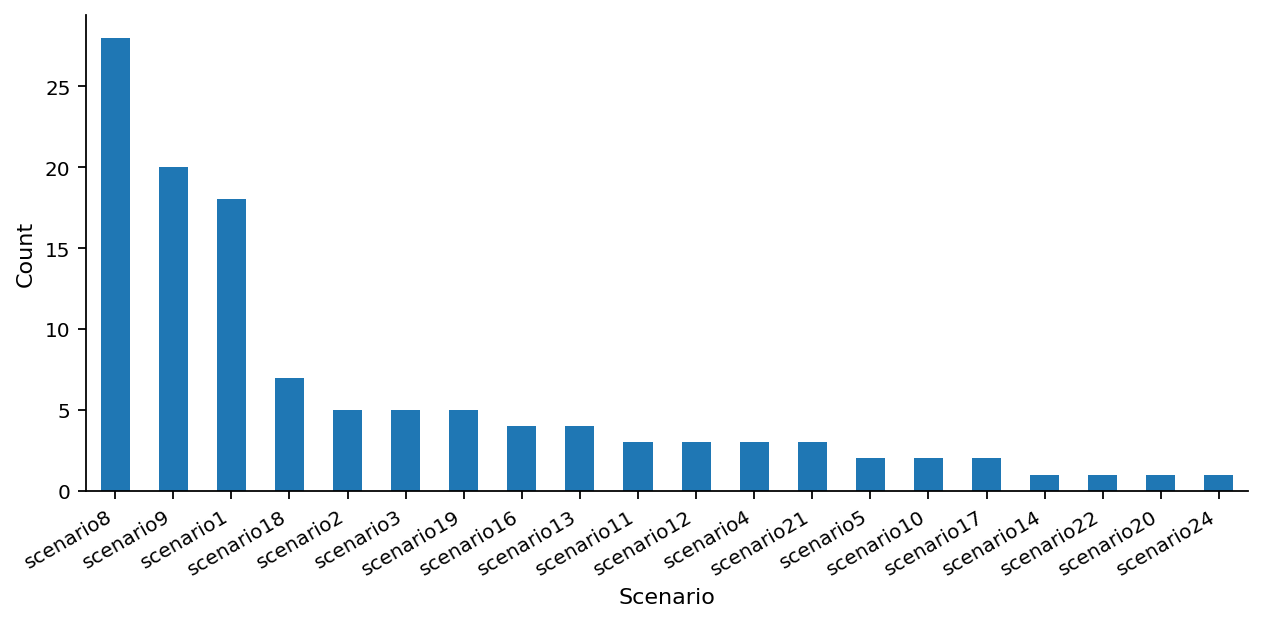

In [78]:
feedback["scenario"].value_counts().plot(kind="bar", figsize=(8, 4))
plt.xlabel("Scenario")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Improvement by Session

In [79]:
session_1 = df[df['session_no']=='session_1'][['user_id'] + all_cols].sort_values("user_id").reset_index(drop=True)
session_2 = df[df['session_no']=='session_2'][['user_id'] + all_cols].sort_values("user_id").reset_index(drop=True)

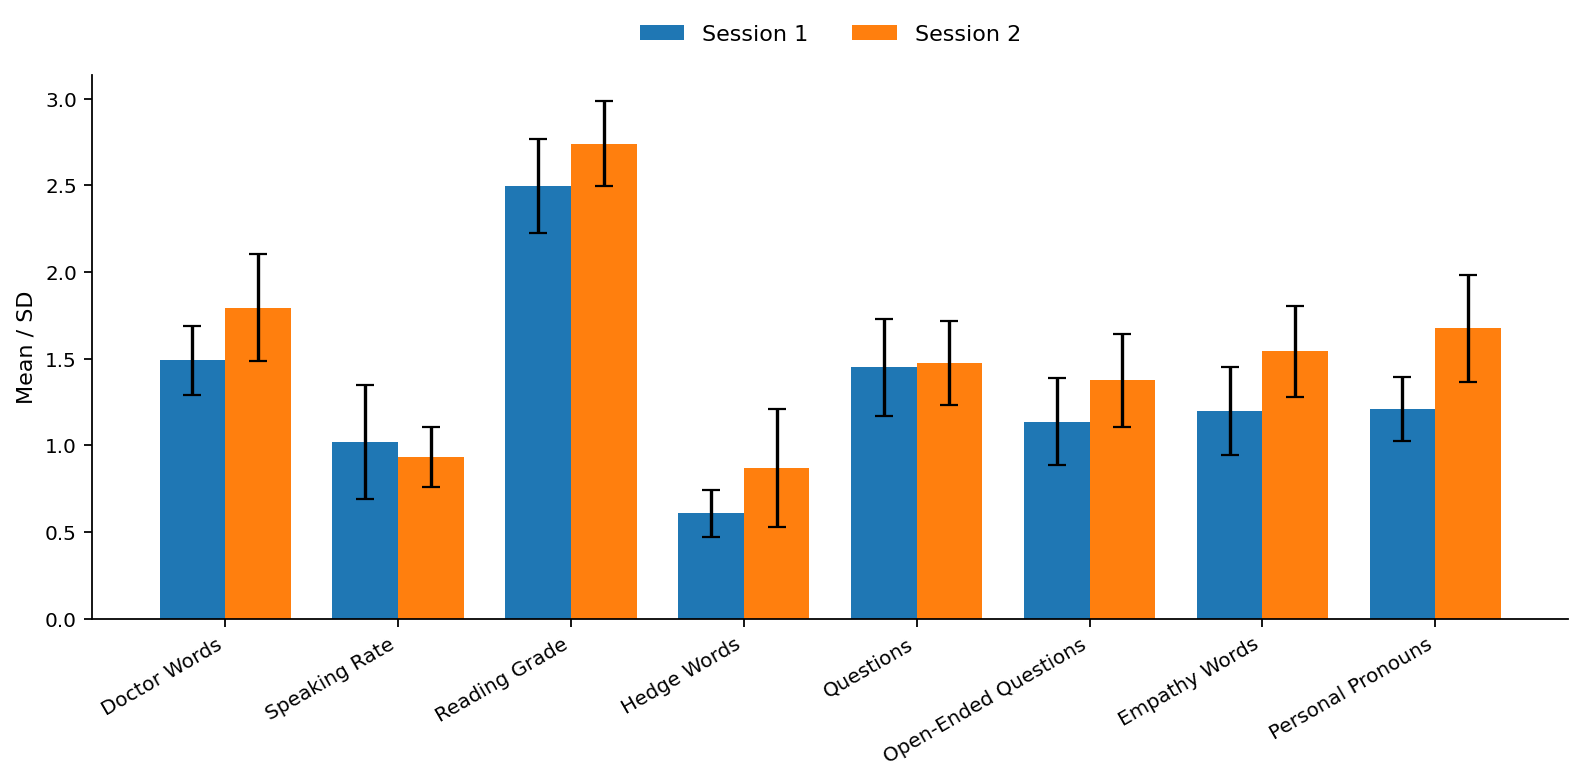

,Metric,N,Session 1 Mean,Session 2 Mean,Difference,95% CI Low,95% CI High,t,p,Significant
0,doctor_total_words,59,28.504,34.295,5.791,1.208,10.375,2.529,0.9929,False
1,speaking_rate,59,217.120,198.757,-18.363,-93.680,56.954,-0.488,0.3137,False
2,reading_grade,59,4.712,5.169,0.458,-0.105,1.021,1.627,0.9454,False
3,num_hedge_words,59,0.085,0.122,0.036,-0.001,0.073,1.974,0.9734,False
4,num_questions,59,0.331,0.336,0.006,-0.079,0.090,0.133,0.5527,False
5,num_open_ended_questions,59,0.159,0.193,0.033,-0.019,0.086,1.274,0.8961,False
6,num_empathy_words,59,0.249,0.321,0.072,0.015,0.129,2.517,0.9927,False
7,personal_pronoun_count,59,1.463,2.026,0.563,0.239,0.887,3.482,0.9995,False


In [80]:
plot_session_comparison(session_1, session_2, feedback_cols, alternative="less", figsize=(10, 5))

## Improvement by LLM

Plotting normalized score for before after in two scenario

- GPT --> HAL
- HAL --> GPT

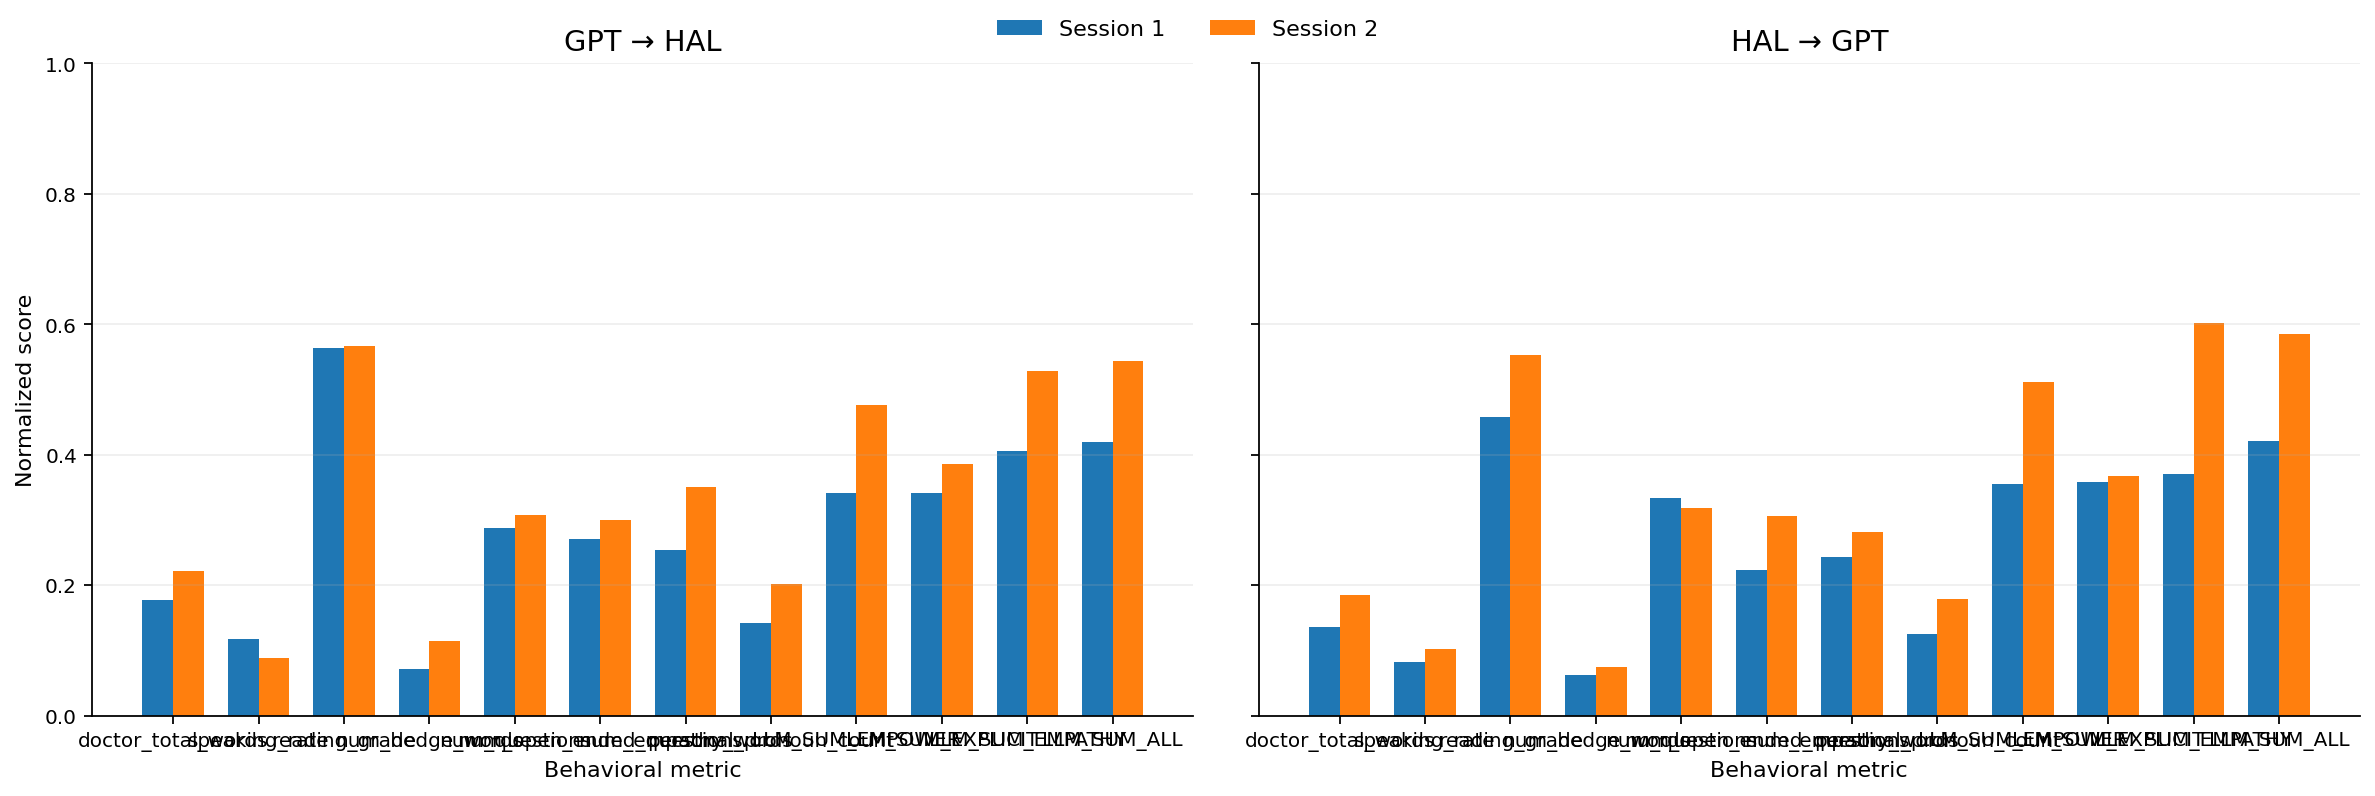

In [83]:
# Determine sequence from session 1
first_llm = (
    df[df["session_no"] == "session_1"]
    .set_index("user_id")["llm_used"]
)

df["sequence"] = df["user_id"].map(first_llm)

# Rename according to your actual llm_used values if needed
df["sequence"] = df["sequence"].replace({
    "GPT-4o-mini": "GPT → HAL",
    "HAL": "HAL → GPT",
})

# Min-max normalize each metric GLOBALLY
norm_metrics = []

for metric in all_cols:
    new_col = metric + "_norm"

    xmin = df[metric].min()
    xmax = df[metric].max()

    df[new_col] = (df[metric] - xmin) / (xmax - xmin)
    norm_metrics.append(new_col)

# Mean normalized score for each sequence × session
summary = (
    df.groupby(["sequence", "session_no"])[norm_metrics]
    .mean()
)

labels = all_cols

sequences = ["GPT → HAL", "HAL → GPT"]

fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharey=True
)

x = np.arange(len(labels))
width = 0.36

for ax, sequence in zip(axes, sequences):

    s1 = summary.loc[(sequence, "session_1"), norm_metrics].values
    s2 = summary.loc[(sequence, "session_2"), norm_metrics].values

    ax.bar(
        x - width/2,
        s1,
        width,
        label="Session 1"
    )

    ax.bar(
        x + width/2,
        s2,
        width,
        label="Session 2"
    )

    ax.set_title(sequence)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Behavioral metric")
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("Normalized score")

# One shared legend
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    legend_labels,
    loc="upper center",
    ncol=2,
    frameon=False
)

# fig.suptitle(
#     "Behavioral Metrics Before and After Interaction",
#     y=1.0
# )

plt.tight_layout()
plt.show()

Plotting normalized score delta in two scenario

- GPT --> HAL
- HAL --> GPT

In [84]:
all_cols

['doctor_total_words',
 'speaking_rate',
 'reading_grade',
 'num_hedge_words',
 'num_questions',
 'num_open_ended_questions',
 'num_empathy_words',
 'personal_pronoun_count',
 'LLM_SUM_EMPOWER',
 'LLM_SUM_EXPLICIT',
 'LLM_SUM_EMPATHY',
 'LLM_SUM_ALL']

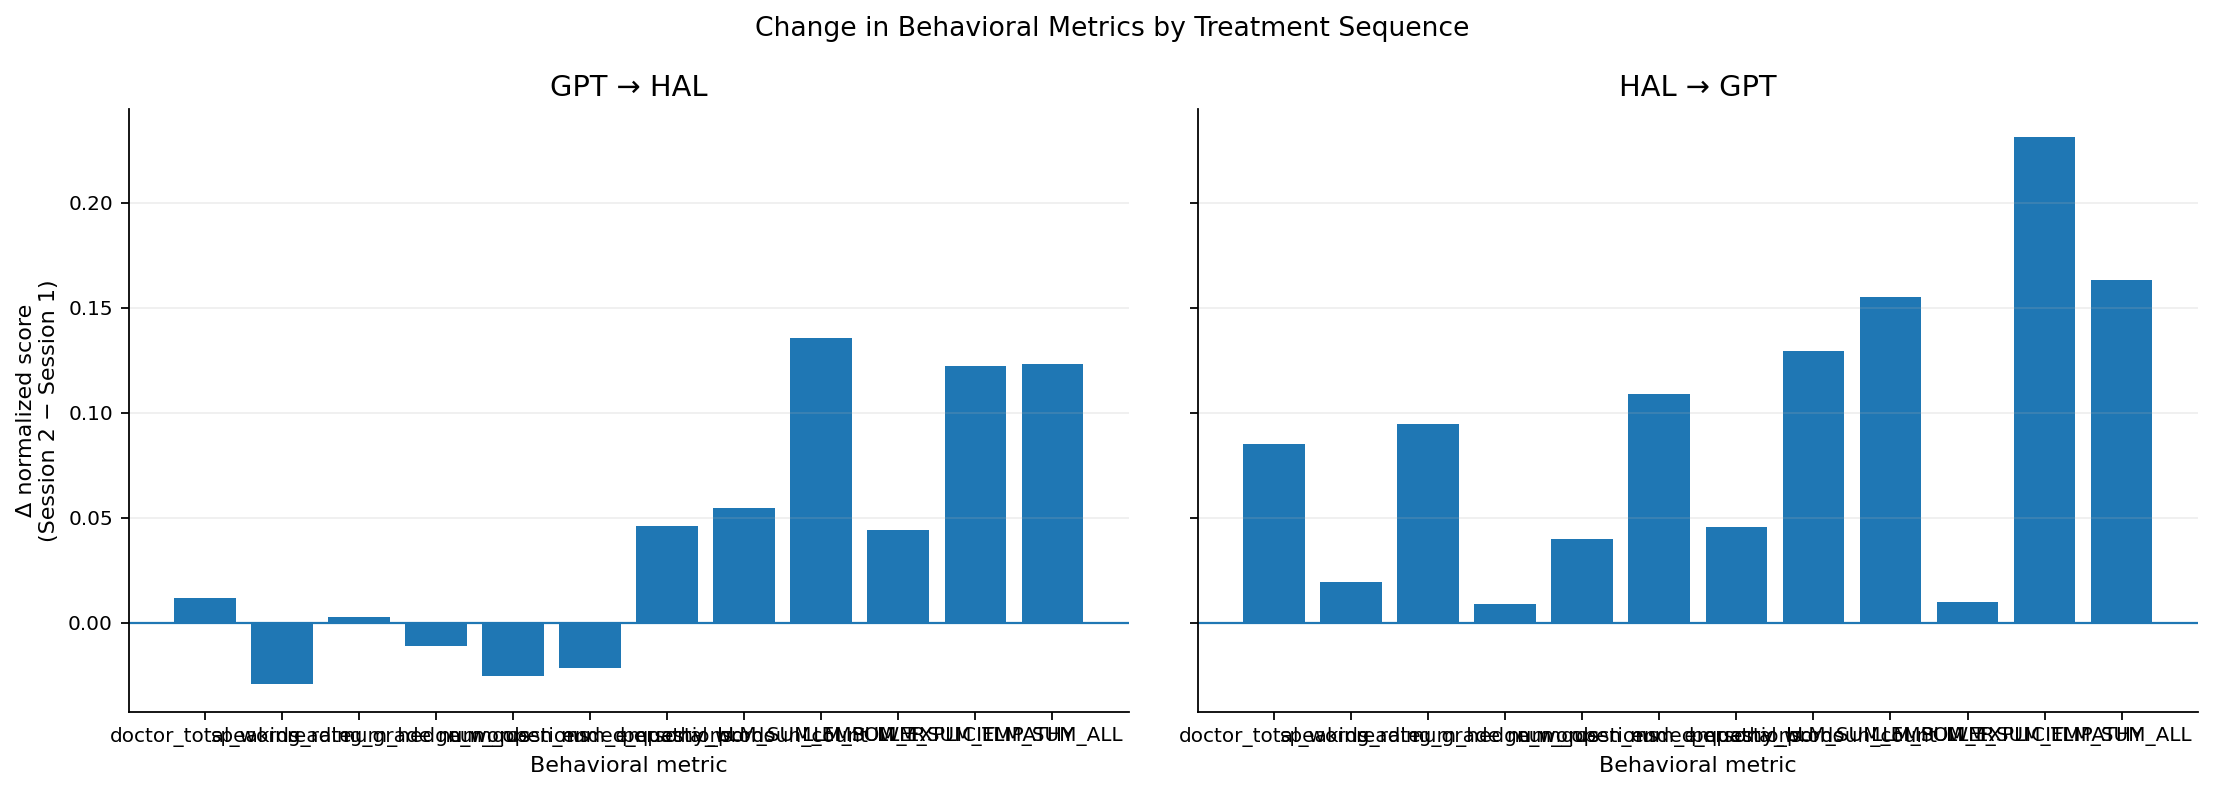

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = valid_interactions.copy()

cols = all_cols
# Numeric
df[cols] = df[cols].apply(
    pd.to_numeric, errors="coerce"
)

# Determine sequence from session 1
first_llm = (
    df[df["session_no"] == "session_1"]
    .set_index("user_id")["llm_used"]
)

df["sequence"] = df["user_id"].map(first_llm).replace({
    "GPT-4o-mini": "GPT → HAL",
    "HAL": "HAL → GPT",
})

# Globally min-max normalize each behavioral metric
norm_metrics = []

for metric in cols:
    col = metric + "_norm"

    xmin = df[metric].min()
    xmax = df[metric].max()

    df[col] = (df[metric] - xmin) / (xmax - xmin)
    norm_metrics.append(col)

# Mean score by sequence and session
summary = (
    df.groupby(["sequence", "session_no"])[norm_metrics]
    .mean()
)

# Delta = Session 2 - Session 1
deltas = {}

for sequence in ["GPT → HAL", "HAL → GPT"]:
    deltas[sequence] = (
        summary.loc[(sequence, "session_2")]
        - summary.loc[(sequence, "session_1")]
    )

labels = cols

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5),
    sharey=True
)

for ax, sequence in zip(axes, ["GPT → HAL", "HAL → GPT"]):

    values = deltas[sequence].values

    ax.bar(
        np.arange(len(labels)),
        values
    )

    ax.axhline(0, linewidth=1)

    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)

    ax.set_title(sequence)
    ax.set_xlabel("Behavioral metric")
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("Δ normalized score\n(Session 2 − Session 1)")

fig.suptitle("Change in Behavioral Metrics by Treatment Sequence")

plt.tight_layout()
plt.show()

### Statistical significance in improvement in HAL --> GPT

In [88]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests


df = valid_interactions.copy()

df[cols] = df[cols].apply(
    pd.to_numeric, errors="coerce"
)

# Determine treatment order from Session 1
first_llm = (
    df[df["session_no"] == "session_1"]
    .set_index("user_id")["llm_used"]
)

sequence = first_llm.replace({
    "HAL": "HAL-first",
    "GPT-4o-mini": "GPT-first",
})

results = []

for metric in all_cols:

    wide = df.pivot_table(
        index="user_id",
        columns="session_no",
        values=metric,
        aggfunc="mean"
    ).dropna(subset=["session_1", "session_2"])

    wide["sequence"] = wide.index.map(sequence)

    # Continuous degree of change
    wide["delta"] = wide["session_2"] - wide["session_1"]

    hal = wide.loc[wide["sequence"] == "HAL-first", "delta"].dropna()
    gpt = wide.loc[wide["sequence"] == "GPT-first", "delta"].dropna()

    # H1: HAL-first produces greater Session 1 -> Session 2 change
    test = ttest_ind(
        hal,
        gpt,
        equal_var=False,
        alternative="greater"
    )

    # Hedges' g
    n1, n2 = len(hal), len(gpt)
    s1, s2 = hal.std(ddof=1), gpt.std(ddof=1)

    pooled_sd = np.sqrt(
        ((n1 - 1) * s1**2 + (n2 - 1) * s2**2)
        / (n1 + n2 - 2)
    )

    d = (hal.mean() - gpt.mean()) / pooled_sd

    # Small-sample correction
    correction = 1 - 3 / (4 * (n1 + n2) - 9)
    hedges_g = d * correction

    results.append({
        "metric": metric,
        "HAL_first_delta": hal.mean(),
        "GPT_first_delta": gpt.mean(),
        "delta_difference": hal.mean() - gpt.mean(),
        "hedges_g": hedges_g,
        "p_value": test.pvalue,
        "n_HAL": n1,
        "n_GPT": n2,
    })

results = pd.DataFrame(results)

# Multiple-comparison correction
results["p_fdr"] = multipletests(
    results["p_value"],
    method="fdr_bh"
)[1]

results["significant_fdr"] = results["p_fdr"] < 0.05

results = results.sort_values("p_value")

display(results)

,metric,HAL_first_delta,GPT_first_delta,delta_difference,hedges_g,p_value,n_HAL,n_GPT,p_fdr,significant_fdr
2,reading_grade,1.040000,0.029412,1.010588,0.470623,0.044089,25,34,0.230654,False
5,num_open_ended_questions,1.200000,-0.235294,1.435294,0.409422,0.057173,25,34,0.230654,False
1,speaking_rate,40.874774,-61.920421,102.795195,0.353536,0.073224,25,34,0.230654,False
10,LLM_SUM_EMPATHY,0.146667,0.077451,0.069216,0.344588,0.094164,25,34,0.230654,False
7,personal_pronoun_count,8.280000,3.500000,4.780000,0.327724,0.106611,25,34,0.230654,False
0,doctor_total_words,87.840000,12.117647,75.722353,0.319280,0.115327,25,34,0.230654,False
4,num_questions,0.600000,-0.382353,0.982353,0.186736,0.239264,25,34,0.396377,False
11,LLM_SUM_ALL,0.079000,0.059559,0.019441,0.166350,0.264251,25,34,0.396377,False
8,LLM_SUM_EMPOWER,0.089778,0.078431,0.011346,0.076985,0.386360,25,34,0.464659,False
3,num_hedge_words,0.480000,-0.588235,1.068235,0.075387,0.387215,25,34,0.464659,False


In [ ]:
# Measure doctor_words_per_turn
# Remove: toatal_words, doctor_total_turns, doctor_total_words
# Or normalize all score by the total number of words
# Make the main story about feedback, not HAL

### Significance across mean delta among all scores

In [91]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind


df = valid_interactions.copy()

df[cols] = df[cols].apply(
    pd.to_numeric, errors="coerce"
)

# --------------------------------
# 1. Globally standardize metrics
# --------------------------------
z_metrics = []

for metric in all_cols:
    col = metric + "_z"

    df[col] = (
        df[metric] - df[metric].mean()
    ) / df[metric].std()

    z_metrics.append(col)

# --------------------------------
# 2. Determine treatment sequence
# --------------------------------
first_llm = (
    df[df["session_no"] == "session_1"]
    .set_index("user_id")["llm_used"]
)

sequence = first_llm.replace({
    "HAL": "HAL-first",
    "GPT-4o-mini": "GPT-first",
})

# --------------------------------
# 3. Get session 1 / session 2 scores
# --------------------------------
wide = df.pivot_table(
    index="user_id",
    columns="session_no",
    values=z_metrics,
    aggfunc="mean"
)

# Delta for every metric
delta = (
    wide.xs("session_2", axis=1, level="session_no")
    - wide.xs("session_1", axis=1, level="session_no")
)

delta.columns = all_cols

# --------------------------------
# 4. Mean delta across ALL metrics
# --------------------------------
delta["mean_delta"] = delta.mean(axis=1)

delta["sequence"] = delta.index.map(sequence)

# --------------------------------
# 5. Compare HAL-first vs GPT-first
# --------------------------------
hal = delta.loc[
    delta["sequence"] == "HAL-first",
    "mean_delta"
].dropna()

gpt = delta.loc[
    delta["sequence"] == "GPT-first",
    "mean_delta"
].dropna()

# H1: HAL-first has greater overall improvement
test = ttest_ind(
    hal,
    gpt,
    equal_var=False,
    alternative="greater"
)

print(f"HAL-first mean delta: {hal.mean():.3f}")
print(f"GPT-first mean delta: {gpt.mean():.3f}")
print(f"Difference: {hal.mean() - gpt.mean():.3f}")
print(f"t = {test.statistic:.3f}")
print(f"p = {test.pvalue:.4f}")

HAL-first mean delta: 0.442
GPT-first mean delta: 0.178
Difference: 0.264
t = 1.507
p = 0.0692


# 3E Scores Analysis

## Previous training analysis

In [95]:
demographic[['user_id', 'urmc_act_training',	'other_communication_training',	'interacted_with_sophie_before']]

,user_id,urmc_act_training,other_communication_training,interacted_with_sophie_before
0,98,0,NaN,0
1,99,0,NaN,0
2,100,0,NaN,0
3,101,0,NaN,0
4,102,0,NaN,0
...,...,...,...,...
105,7,0,General training as a student and resident,0
106,8,0,NaN,0
107,9,0,NaN,0
108,1,0,NaN,0


In [99]:
df[['user_id'] + eee_cols]

,user_id,LLM_SUM_EMPOWER,LLM_SUM_EXPLICIT,LLM_SUM_EMPATHY,LLM_SUM_ALL
0,114,0.244444,0.400000,0.333333,0.308333
1,114,0.288889,0.314286,0.166667,0.250000
2,113,0.488889,0.428571,0.400000,0.450000
3,113,0.333333,0.400000,0.166667,0.300000
4,112,0.333333,0.371429,0.500000,0.383333
...,...,...,...,...,...
113,9,0.422222,0.457143,0.466667,0.441667
114,7,0.600000,0.514286,0.666667,0.583333
115,7,0.422222,0.542857,0.600000,0.500000
116,5,0.288889,0.428571,0.566667,0.408333


In [100]:
import numpy as np
import pandas as pd
from scipy.stats import pointbiserialr, ttest_ind

experience_cols = [
    "urmc_act_training",
    "other_communication_training",
    "interacted_with_sophie_before",
]

# Treat non-empty, affirmative responses as previous experience
false_values = {
    "", "0", "0.0", "no", "false", "none",
    "nan", "na", "n/a", "not applicable",
}

def indicates_experience(series):
    cleaned = series.astype("string").str.strip().str.lower()
    return series.notna() & ~cleaned.isin(false_values)


# Prepare demographics
demo = demographic[["user_id"] + experience_cols].copy()
demo["user_id"] = pd.to_numeric(demo["user_id"], errors="coerce")

demo["previous_experience"] = np.logical_or.reduce([
    indicates_experience(demo[col])
    for col in experience_cols
])

demo = demo.dropna(subset=["user_id"]).drop_duplicates("user_id")


# Average repeated scores within each participant
scores = df[["user_id", "LLM_SUM_ALL"]].copy()
scores["user_id"] = pd.to_numeric(scores["user_id"], errors="coerce")
scores["LLM_SUM_ALL"] = pd.to_numeric(
    scores["LLM_SUM_ALL"], errors="coerce"
)

scores = (
    scores.dropna()
    .groupby("user_id", as_index=False)["LLM_SUM_ALL"]
    .mean()
)


# Merge demographics with participant-level scores
analysis = demo.merge(scores, on="user_id", how="inner")

analysis["experience_group"] = analysis["previous_experience"].map({
    True: "Any previous experience",
    False: "No previous experience",
})


# Descriptive statistics
summary = (
    analysis.groupby("experience_group")["LLM_SUM_ALL"]
    .agg(n="count", mean="mean", sd="std", median="median")
    .round(3)
)

experienced = analysis.loc[
    analysis["previous_experience"], "LLM_SUM_ALL"
]

not_experienced = analysis.loc[
    ~analysis["previous_experience"], "LLM_SUM_ALL"
]


# Point-biserial correlation
r, correlation_p = pointbiserialr(
    analysis["previous_experience"].astype(int),
    analysis["LLM_SUM_ALL"],
)

# One-sided Welch test: previous experience > no experience
test = ttest_ind(
    experienced,
    not_experienced,
    equal_var=False,
    alternative="greater",
)

mean_difference = experienced.mean() - not_experienced.mean()

print(summary)
print(f"\nMean difference: {mean_difference:.3f}")
print(f"Point-biserial r: {r:.3f}, two-sided p = {correlation_p:.4f}")
print(f"Welch t = {test.statistic:.3f}, one-sided p = {test.pvalue:.4f}")

                          n   mean     sd  median
experience_group                                 
Any previous experience  16  0.468  0.061   0.452
No previous experience   43  0.426  0.060   0.438

Mean difference: 0.042
Point-biserial r: 0.301, two-sided p = 0.0204
Welch t = 2.368, one-sided p = 0.0127


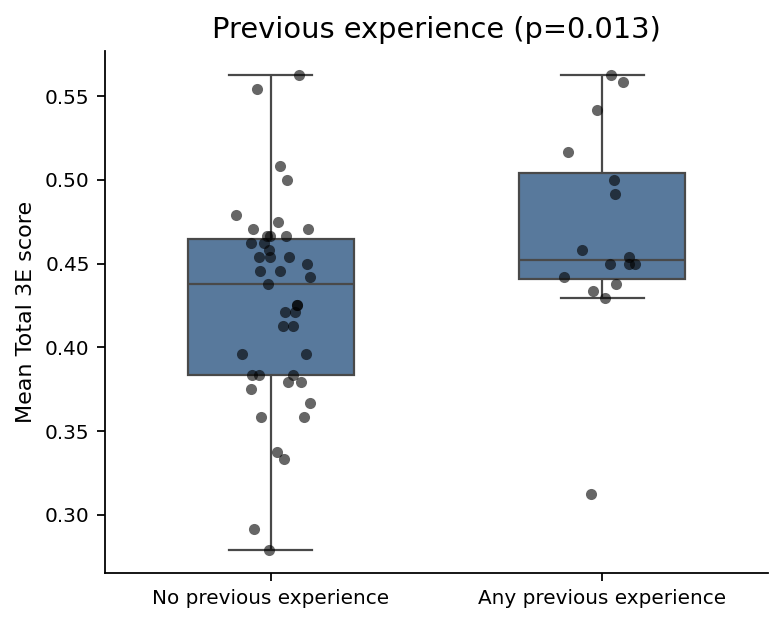

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))

sns.boxplot(
    data=analysis,
    x="experience_group",
    y="LLM_SUM_ALL",
    order=["No previous experience", "Any previous experience"],
    color="#4C78A8",
    width=0.5,
    showfliers=False,
    ax=ax,
)

sns.stripplot(
    data=analysis,
    x="experience_group",
    y="LLM_SUM_ALL",
    order=["No previous experience", "Any previous experience"],
    color="black",
    alpha=0.6,
    jitter=0.12,
    ax=ax,
)

ax.set(
    xlabel="",
    ylabel="Mean Total 3E score",
    title=f"Previous experience (p={test.pvalue:.3f})",
)
plt.tight_layout()
plt.show()

## Improvement by Session

In [104]:
session_1 = df[df['session_no']=='session_1'][['user_id'] + all_cols].sort_values("user_id").reset_index(drop=True)
session_2 = df[df['session_no']=='session_2'][['user_id'] + all_cols].sort_values("user_id").reset_index(drop=True)

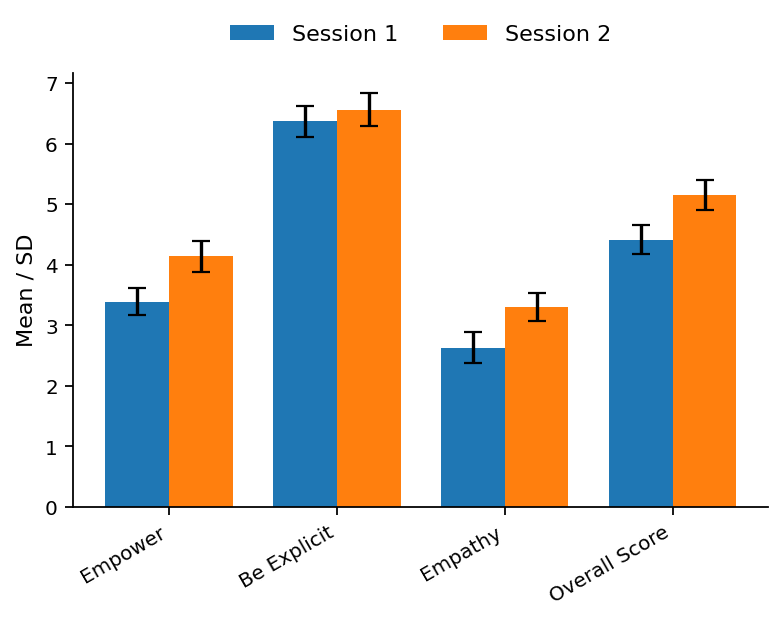

,Metric,N,Session 1 Mean,Session 2 Mean,Difference,95% CI Low,95% CI High,t,p,Significant
0,LLM_SUM_EMPOWER,59,0.378,0.461,0.083,0.046,0.121,4.431,0.0000,True
1,LLM_SUM_EXPLICIT,59,0.445,0.459,0.014,-0.009,0.036,1.185,0.1204,False
2,LLM_SUM_EMPATHY,59,0.414,0.521,0.107,0.055,0.159,4.111,0.0001,True
3,LLM_SUM_ALL,59,0.403,0.471,0.068,0.038,0.098,4.539,0.0000,True


In [105]:
plot_session_comparison(session_1, session_2, eee_cols, figsize=(5, 4))

## Improvement by LLM

### GPT vs HAL

In [106]:
gpt = df[df['llm_used']=='GPT-4o-mini'][['user_id'] + all_cols].sort_values("user_id").reset_index(drop=True)
hal = df[df['llm_used']=='HAL'][['user_id'] + all_cols].sort_values("user_id").reset_index(drop=True)

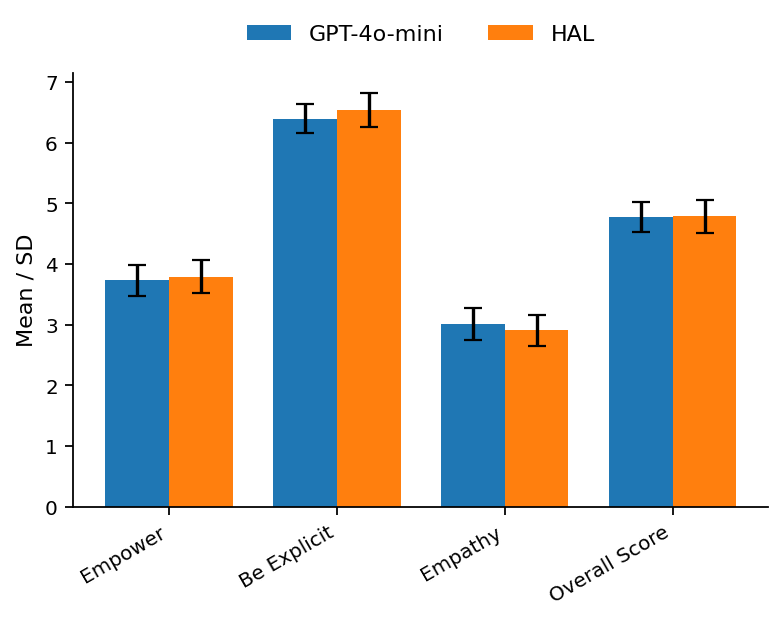

,Metric,N,GPT-4o-mini Mean,HAL Mean,Difference,95% CI Low,95% CI High,t,p,Significant
0,LLM_SUM_EMPOWER,59,0.416,0.423,0.007,-0.036,0.051,0.330,0.3714,False
1,LLM_SUM_EXPLICIT,59,0.447,0.457,0.010,-0.013,0.033,0.842,0.2017,False
2,LLM_SUM_EMPATHY,59,0.476,0.459,-0.018,-0.076,0.041,-0.595,0.7230,False
3,LLM_SUM_ALL,59,0.437,0.438,0.001,-0.034,0.036,0.049,0.4806,False


In [107]:
plot_session_comparison(gpt, hal, eee_cols, "GPT-4o-mini", "HAL", figsize=(5, 4))
# This is wrong. We should compare improvement made by GPT against improvement made by HAL

### GPT-->HAL vs HAL-->GPT

In [108]:
df

,user_id,user_group,feedback_id,llm_used,meeting_duration_seconds,timestamp_utc,transcript,LLM_SUM_EMPOWER,LLM_SUM_EXPLICIT,LLM_SUM_EMPATHY,...,reading_grade_z,num_hedge_words_z,num_questions_z,num_open_ended_questions_z,num_empathy_words_z,personal_pronoun_count_z,LLM_SUM_EMPOWER_z,LLM_SUM_EXPLICIT_z,LLM_SUM_EMPATHY_z,LLM_SUM_ALL_z
0,114,GROUP_006,218,HAL,192.993247,2026-08-01 13:22:58,[Redacted],0.244444,0.400000,0.333333,...,1.091354,-0.794842,-1.226862,-0.813077,-0.959434,0.133119,-1.571381,-0.741493,-0.850831,-1.409612
1,114,GROUP_006,217,GPT-4o-mini,203.878303,2026-08-01 13:17:42,[Redacted],0.288889,0.314286,0.166667,...,1.621311,-0.444220,-0.960742,-1.216200,-0.232154,-0.515974,-1.173050,-1.968076,-1.907652,-2.047957
2,113,GROUP_006,214,GPT-4o-mini,520.128477,2026-07-31 13:42:55,[Redacted],0.488889,0.428571,0.400000,...,0.561396,2.974345,0.635984,0.396290,0.979979,2.275128,0.619438,-0.332633,-0.428102,0.140652
3,113,GROUP_006,213,HAL,276.150958,2026-07-31 13:30:20,[Redacted],0.333333,0.400000,0.166667,...,-0.498520,1.396545,0.902105,-0.409955,-0.232154,-0.515974,-0.774719,-0.741493,-1.907652,-1.500804
4,112,GROUP_006,211,GPT-4o-mini,347.119841,2026-07-30 19:05:52,[Redacted],0.333333,0.371429,0.500000,...,-0.498520,0.519990,2.498830,1.605657,-1.201861,0.522575,-0.774719,-1.150354,0.205991,-0.588884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,9,GROUP_004,36,HAL,293.501492,2026-04-18 09:43:32,[Redacted],0.422222,0.457143,0.466667,...,-0.498520,0.958268,0.635984,-0.409955,0.979979,-0.386156,0.021942,0.076228,-0.005374,0.049460
114,7,GROUP_004,34,HAL,325.495486,2026-04-13 11:10:36,[Redacted],0.600000,0.514286,0.666667,...,-1.028477,-0.970153,-0.428500,-0.813077,-0.717008,0.652394,1.615265,0.893950,1.262812,1.599725
115,7,GROUP_004,33,GPT-4o-mini,308.604378,2026-04-13 11:00:37,[Redacted],0.422222,0.542857,0.600000,...,-1.028477,0.519990,0.369863,0.799412,0.252699,-0.126518,0.021942,1.302811,0.840083,0.687804
116,5,GROUP_004,32,HAL,377.168082,2026-04-10 10:26:57,[Redacted],0.288889,0.428571,0.566667,...,2.681227,-0.093598,-1.226862,-0.813077,0.979979,0.327847,-1.173050,-0.332633,0.628719,-0.315308


In [109]:
session_1 = df[df['session_no']=='session_1'][['user_id', 'llm_used'] + eee_cols].sort_values("user_id").reset_index(drop=True)
session_2 = df[df['session_no']=='session_2'][['user_id', 'llm_used'] + eee_cols].sort_values("user_id").reset_index(drop=True)

In [110]:
session_1_gpt = session_1[session_1['llm_used'] == 'GPT-4o-mini'][eee_cols].reset_index(drop=True)
session_1_hal = session_1[session_1['llm_used'] == 'HAL'][eee_cols].reset_index(drop=True)

session_2_gpt = session_1[session_1['llm_used'] == 'GPT-4o-mini'][eee_cols].reset_index(drop=True)
session_2_hal = session_1[session_1['llm_used'] == 'HAL'][eee_cols].reset_index(drop=True)

gpt_hal = session_2_hal - session_1_gpt
hal_gpt = session_2_gpt - session_1_hal

In [111]:
gpt_hal

,LLM_SUM_EMPOWER,LLM_SUM_EXPLICIT,LLM_SUM_EMPATHY,LLM_SUM_ALL
0,0.000000,0.028571,-0.100000,-0.016667
1,0.244444,0.142857,-0.100000,0.116667
2,0.000000,-0.057143,-0.200000,-0.066667
3,-0.177778,0.000000,-0.066667,-0.100000
4,-0.088889,-0.028571,0.066667,-0.033333
5,-0.044444,0.057143,-0.266667,-0.075000
6,-0.022222,0.000000,-0.033333,-0.016667
7,0.022222,-0.057143,0.066667,0.016667
8,0.200000,0.142857,0.033333,0.141667
9,-0.177778,0.000000,0.066667,-0.041667


In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, t

def plot_delta_comparison(gpt_hal, hal_gpt, cols, figsize=(10, 5)):
    groups = {"GPT → HAL": gpt_hal, "HAL → GPT": hal_gpt}
    x, w = np.arange(len(cols)), .38

    means, cis = {}, {}
    for name, d in groups.items():
        means[name] = d[cols].mean()
        n = d[cols].count()
        cis[name] = d[cols].sem() * t.ppf(.975, n - 1)

    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(x-w/2, means["GPT → HAL"], w, yerr=cis["GPT → HAL"], capsize=4, label="GPT → HAL")
    ax.bar(x+w/2, means["HAL → GPT"], w, yerr=cis["HAL → GPT"], capsize=4, label="HAL → GPT")
    ax.axhline(0, color="black", lw=.8)
    ax.set_xticks(x, [label_map.get(c, c) for c in cols], rotation=30, ha="right")
    ax.set_ylabel("Mean change")
    ax.legend(loc="lower center", bbox_to_anchor=(.5, 1.02), ncol=2, frameon=False)
    plt.tight_layout()
    plt.show()

    rows = []
    for c in cols:
        a, b = gpt_hal[c].dropna(), hal_gpt[c].dropna()
        stat, p = ttest_ind(b, a, equal_var=False, alternative="greater")
        rows.append([c, len(a), len(b), a.mean(), b.mean(), b.mean()-a.mean(), stat, p, p < .05])

    results = pd.DataFrame(rows, columns=[
        "Metric", "N GPT→HAL", "N HAL→GPT", "GPT→HAL Mean",
        "HAL→GPT Mean", "Difference", "t", "p", "Significant"
    ])

    display(results.style.format({
        "GPT→HAL Mean": "{:.3f}", "HAL→GPT Mean": "{:.3f}",
        "Difference": "{:.3f}", "t": "{:.3f}", "p": "{:.4f}"
    }))

    return results

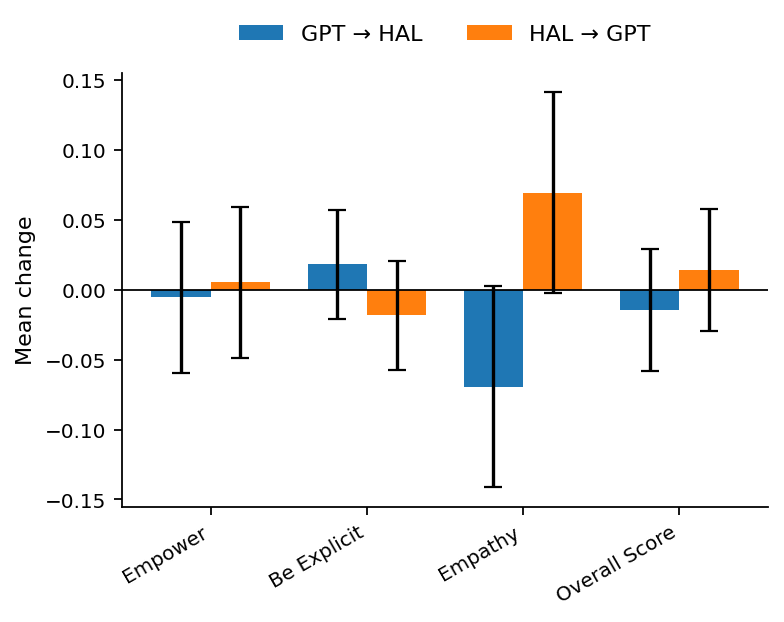

,Metric,N GPT→HAL,N HAL→GPT,GPT→HAL Mean,HAL→GPT Mean,Difference,t,p,Significant
0,LLM_SUM_EMPOWER,25,25,-0.005,0.005,0.011,0.288,0.3874,False
1,LLM_SUM_EXPLICIT,25,25,0.018,-0.018,-0.037,-1.365,0.9107,False
2,LLM_SUM_EMPATHY,25,25,-0.069,0.069,0.139,2.818,0.0035,True
3,LLM_SUM_ALL,25,25,-0.014,0.014,0.029,0.956,0.1720,False


In [113]:
results = plot_delta_comparison(gpt_hal, hal_gpt, eee_cols, figsize=(5,4))